# Data augmentation 

This notebook is used to test different augmentation strategies and their impact on model performance.

In [297]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
torch.manual_seed(42)


def segment_data_with_activity_local(df, subjects, w=2, o=0.75, fs=60,
                                     activity_col_candidates=('activity', 'activityID', 'task', 'taskID')):
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]

    activity_col = next((c for c in activity_col_candidates if c in df.columns), None)
    if activity_col is None:
        return None, None, None, None

    win_size = int(w * fs)
    step = int(win_size * (1 - o))

    X, y, a = [], [], []
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        if sub_df.empty:
            continue

        data = sub_df[cols].values
        labels = sub_df['fog'].values
        acts = sub_df[activity_col].values

        for i in range(0, len(data) - win_size, step):
            window = data[i:i + win_size]
            window_rel = window - window[0]
            y_mode = pd.Series(labels[i:i + win_size]).mode()[0]
            a_mode = pd.Series(acts[i:i + win_size]).mode()[0]

            X.append(window_rel)
            y.append(int(y_mode))
            a.append(int(a_mode))

    return np.array(X), np.array(y), np.array(a), activity_col

In [298]:
import numpy as np

def augment_quaternion_window(x, noise_std=0.01, scale_std=0.03, time_jitter=2):
    # x shape: (T, C)
    x_aug = x.copy()

    # 1) small additive noise
    x_aug += np.random.normal(0.0, noise_std, size=x_aug.shape)

    # 2) small multiplicative scaling per channel
    scales = 1.0 + np.random.normal(0.0, scale_std, size=(1, x_aug.shape[1]))
    x_aug = x_aug * scales

    # 3) tiny temporal shift
    if time_jitter > 0:
        shift = np.random.randint(-time_jitter, time_jitter + 1)
        x_aug = np.roll(x_aug, shift=shift, axis=0)

    # --- LIGNE MAGIQUE POUR SAUVER LA PHYSIQUE DES QUATERNIONS ---
    # On suppose que x_aug a 12 canaux (3 capteurs * 4 valeurs : w, x, y, z)
    # On normalise chaque bloc de 4 valeurs (chaque capteur) pour forcer la norme à 1
    for i in range(0, x_aug.shape[1], 4):
        quat_sensor = x_aug[:, i:i+4]
        # Calcul de la norme pour chaque pas de temps
        norms = np.linalg.norm(quat_sensor, axis=1, keepdims=True)
        # On évite la division par zéro au cas où
        norms[norms == 0] = 1e-8
        # On re-normalise le quaternion
        x_aug[:, i:i+4] = quat_sensor / norms

    return x_aug

In [299]:
def build_augmented_train_set(X, y, a=None, mode='global',
                              hard_activity_ids=None,
                              n_aug_global=1,
                              n_aug_fog=2,
                              n_aug_fog_hard=5):
    X_aug_list = [X]
    y_aug_list = [y]

    if mode == 'global':
        idx = np.arange(len(X))
        for _ in range(n_aug_global):
            X_aug = np.array([augment_window(X[i]) for i in idx])
            X_aug_list.append(X_aug)
            y_aug_list.append(y[idx])

    elif mode == 'fog':
        idx = np.where(y == 1)[0]
        for _ in range(n_aug_fog):
            X_aug = np.array([augment_window(X[i]) for i in idx])
            X_aug_list.append(X_aug)
            y_aug_list.append(y[idx])

    elif mode == 'fog_hard':
        if (a is None) or (hard_activity_ids is None) or (len(hard_activity_ids) == 0):
            raise ValueError("Mode 'fog_hard' nécessite activity labels + hard_activity_ids.")
        idx = np.where((y == 1) & np.isin(a, hard_activity_ids))[0]
        for _ in range(n_aug_fog_hard):
            X_aug = np.array([augment_window(X[i]) for i in idx])
            X_aug_list.append(X_aug)
            y_aug_list.append(y[idx])

    X_out = np.concatenate(X_aug_list, axis=0)
    y_out = np.concatenate(y_aug_list, axis=0)
    return X_out, y_out

In [300]:
def train_eval_single_run(X_train_in, y_train_in, X_val_in, y_val_in,
                          X_test_in, y_test_in,
                          epochs=40, lr=0.001, threshold=0.4,
                          plot_losses=False, run_name=''):

    train_ds = FogDataset(X_train_in, y_train_in)
    val_ds = FogDataset(X_val_in, y_val_in)
    test_ds = FogDataset(X_test_in, y_test_in)

    train_ld = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
    val_ld = torch.utils.data.DataLoader(val_ds, batch_size=64, shuffle=False)
    test_ld = torch.utils.data.DataLoader(test_ds, batch_size=64, shuffle=False)

    run_model = MultiBranchCNN().to(device)
    optimizer = torch.optim.Adam(run_model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.BCELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=4, factor=0.5)

    best_state = None
    best_val_loss = float('inf')
    best_epoch = 0

    # Keep full training history for plotting
    train_history = []
    val_history = []

    for epoch in range(epochs):
        print(f'Epoch {epoch + 1}/{epochs}')
        run_model.train()
        train_losses = []
        for inputs, labels in train_ld:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            probs = run_model(inputs).squeeze()
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        run_model.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, labels in val_ld:
                inputs, labels = inputs.to(device), labels.to(device)
                probs = run_model(inputs).squeeze()
                v_loss = criterion(probs, labels)
                val_losses.append(v_loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        train_history.append(train_loss)
        val_history.append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in run_model.state_dict().items()}

    # Snapshot of the very last epoch model (epoch = epochs)
    last_state = {k: v.detach().cpu().clone() for k, v in run_model.state_dict().items()}

    if plot_losses:
        import matplotlib.pyplot as plt

        epochs_axis = np.arange(1, len(train_history) + 1)
        plt.figure(figsize=(10, 4.5))
        plt.plot(epochs_axis, train_history, label='Train loss', linewidth=2)
        plt.plot(epochs_axis, val_history, label='Validation loss', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        title_suffix = f' - {run_name}' if run_name else ''
        plt.title(f'Loss curves{title_suffix}')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def metrics_from_probs(y_true, y_prob, thr):
        y_pred = (y_prob > thr).astype(int)
        return {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
        }

    def best_threshold_on_val(y_true, y_prob, thresholds=None):
        if thresholds is None:
            thresholds = np.linspace(0.1, 0.9, 33)
        best_thr = float(thresholds[0])
        best_f1 = -1.0
        for thr in thresholds:
            f1 = f1_score(y_true, (y_prob > thr).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = float(thr)
        return best_thr, float(best_f1)

    def eval_state(state_dict):
        run_model.load_state_dict(state_dict)
        run_model.eval()

        def collect_probs(loader):
            all_probs = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in loader:
                    inputs = inputs.to(device)
                    probs = run_model(inputs).squeeze()
                    if probs.dim() == 0:
                        probs = probs.unsqueeze(0)
                    all_probs.extend(probs.cpu().numpy().tolist())
                    all_targets.extend(labels.cpu().numpy().tolist())
            return np.array(all_targets, dtype=int), np.array(all_probs, dtype=float)

        y_val_true, y_val_prob = collect_probs(val_ld)
        y_test_true, y_test_prob = collect_probs(test_ld)

        default_metrics_test = metrics_from_probs(y_test_true, y_test_prob, threshold)
        val_best_thr, val_best_f1 = best_threshold_on_val(y_val_true, y_val_prob)
        tuned_metrics_test = metrics_from_probs(y_test_true, y_test_prob, val_best_thr)

        return {
            'val_true': y_val_true.tolist(),
            'val_prob': y_val_prob.tolist(),
            'test_true': y_test_true.tolist(),
            'test_prob': y_test_prob.tolist(),
            'metrics_at_input_threshold': default_metrics_test,
            'best_threshold_from_val_f1': val_best_thr,
            'best_val_f1': val_best_f1,
            'test_metrics_at_best_val_threshold': tuned_metrics_test,
        }

    best_eval = eval_state(best_state)
    last_eval = eval_state(last_state)

    # Keep model in best-validation state by default after training
    run_model.load_state_dict(best_state)

    best_metrics = best_eval['metrics_at_input_threshold']
    last_metrics = last_eval['metrics_at_input_threshold']

    return {
        # Backward-compatible top-level metrics = best checkpoint at input threshold
        'accuracy': best_metrics['accuracy'],
        'precision': best_metrics['precision'],
        'recall': best_metrics['recall'],
        'f1': best_metrics['f1'],
        'threshold': threshold,
        'epochs': epochs,
        'train_size': len(y_train_in),
        'fog_rate_train': float(y_train_in.mean()),
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'last_epoch': epochs,
        'train_loss_history': train_history,
        'val_loss_history': val_history,
        'best_metrics': best_metrics,
        'last_metrics': last_metrics,
        'delta_f1_last_minus_best': last_metrics['f1'] - best_metrics['f1'],
        # New rich payloads for threshold sweep and per-subject analysis
        'best_eval': best_eval,
        'last_eval': last_eval,
        'best_model_state': best_state
    }


In [352]:
def run_aug_experiment(mode, hard_activity_ids=None, plot_losses=False):
    # Build train set with requested augmentation policy
    X_train_activity, y_train_activity, a_train_activity, activity_col = segment_data_with_activity_local(
        df_quat, train_subjects, w=2, o=0.75, fs=60
    )

    # Fallback: if activity not found, use existing X_train/y_train
    if X_train_activity is None:
        X_base, y_base, a_base = X_train, y_train, None
    else:
        X_base, y_base, a_base = X_train_activity, y_train_activity, a_train_activity

    X_aug, y_aug = build_augmented_train_set(
        X_base, y_base, a=a_base, mode=mode, hard_activity_ids=hard_activity_ids,
        n_aug_global=1, n_aug_fog=2, n_aug_fog_hard=10
    )

    metrics = train_eval_single_run(
        X_train_in=X_aug, y_train_in=y_aug,
        X_val_in=X_val, y_val_in=y_val,
        X_test_in=X_test, y_test_in=y_test,
        epochs=40, lr=0.001, threshold=0.4,
        plot_losses=plot_losses, run_name=f'augmentation={mode}'
    )
    metrics['mode'] = mode
    return metrics


## Load data and model

In [ ]:
train_subjects = [2, 3, 10, 12, 13, 14, 16, 17, 18, 21]
val_subjects = [1, 5, 6, 7, 11, 15, 20]
test_subjects = [4, 8, 9, 19, 22]  

In [357]:
df_quat = pd.read_csv('sensor_data_quaternions.csv')

In [358]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiBranchCNN(nn.Module):
    def __init__(self):
        super(MultiBranchCNN, self).__init__()
        
        # Branch 1: Ankles (8 channels: Left q0-q3 + Right q0-q3)
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Reduces to a single vector
        )
        
        # Branch 2: Back (4 channels: Back q0-q3)
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Fusion Layer: Combines 128 (Ankles) + 64 (Back) = 192 features
        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x is assumed to be (Batch, Channels, Time) -> (Batch, 12, 120)
        ankles = x[:, 0:8, :] # First 8 channels
        back = x[:, 8:12, :]  # Last 4 channels
        
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back = self.back_branch(back).view(x.size(0), -1)
        
        # Concatenate branches
        combined = torch.cat((feat_ankles, feat_back), dim=1)
        return self.classifier(combined)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MultiBranchCNN().to(device)
print(f"Model initialized on: {device}")

Model initialized on: mps


In [359]:
def segment_data(df, subjects, w=2, o=0.75, fs=60):
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    # Order matters for the Multi-Branch CNN: 8 Ankle channels first, 4 Back channels last
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X, y = [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        data = sub_df[cols].values
        labels = sub_df['fog'].values
        
        for i in range(0, len(data) - win_size, step):
            window = data[i : i + win_size]
            # --- RELATIVE TRANSFORMATION ---
            # Subtract the first sample of the window from the whole window
            window_rel = window - window[0]
            
            X.append(window_rel)
            # Use the mode (most frequent) label for the window
            y.append(pd.Series(labels[i : i + win_size]).mode()[0])
            
    return np.array(X), np.array(y)

# Load your generated quaternions file
df_quat = pd.read_csv('sensor_data_quaternions.csv')

print("Segmenting datasets...")
X_val, y_val     = segment_data(df_quat, val_subjects)
X_test, y_test   = segment_data(df_quat, test_subjects)

Segmenting datasets...


In [360]:
import torch
from torch.utils.data import Dataset, DataLoader

class FogDataset(Dataset):
    def __init__(self, X, y):
        # Convert to float32 and move to tensors
        # X shape from segmentation: (Samples, Time, Channels) -> e.g., (N, 120, 12)
        # PyTorch Conv1d expects: (Samples, Channels, Time) -> e.g., (N, 12, 120)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Epoch 1/40
Epoch 2/40
Epoch 3/40
Epoch 4/40
Epoch 5/40
Epoch 6/40
Epoch 7/40
Epoch 8/40
Epoch 9/40
Epoch 10/40
Epoch 11/40
Epoch 12/40
Epoch 13/40
Epoch 14/40
Epoch 15/40
Epoch 16/40
Epoch 17/40
Epoch 18/40
Epoch 19/40
Epoch 20/40
Epoch 21/40
Epoch 22/40
Epoch 23/40
Epoch 24/40
Epoch 25/40
Epoch 26/40
Epoch 27/40
Epoch 28/40
Epoch 29/40
Epoch 30/40
Epoch 31/40
Epoch 32/40
Epoch 33/40
Epoch 34/40
Epoch 35/40
Epoch 36/40
Epoch 37/40
Epoch 38/40
Epoch 39/40
Epoch 40/40


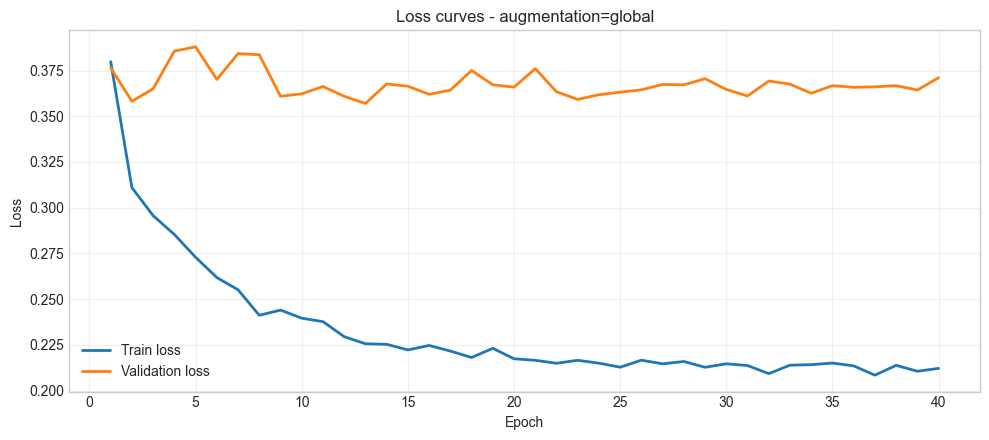

Global augmentation metrics:
{'accuracy': 0.8438262567105905, 'precision': 0.6005154639175257, 'recall': 0.585427135678392, 'f1': 0.5928753180661578, 'threshold': 0.4, 'epochs': 40, 'train_size': 8756, 'fog_rate_train': 0.19392416628597534, 'best_val_loss': 0.3569943679350556, 'best_epoch': 13, 'last_epoch': 40, 'train_loss_history': [0.3798622095236813, 0.3109796600837777, 0.29565150230905435, 0.28534915847499875, 0.2728939493642236, 0.2618095965063485, 0.25510742934080805, 0.2411578589112219, 0.24400830366750703, 0.23957357022666584, 0.23769010744825766, 0.22946423493380094, 0.2255845005168532, 0.22528843304319104, 0.22223394505516456, 0.2246699194512228, 0.22161074765842326, 0.2180687229346185, 0.22310485467858557, 0.21737971445069695, 0.2165387140682144, 0.21491433897592727, 0.21654066889390458, 0.21496625445837522, 0.21276693323450366, 0.2166062084971553, 0.21460872518755222, 0.21588249760170053, 0.21272357487983076, 0.21463538804193483, 0.21367233567429286, 0.20924680718105204, 0

In [361]:
# Step 1/3: Global augmentation
metrics_global = run_aug_experiment(mode='global', plot_losses=True)
print('Global augmentation metrics:')

print(metrics_global)

Epoch 1/40
Epoch 2/40
Epoch 3/40
Epoch 4/40
Epoch 5/40
Epoch 6/40
Epoch 7/40
Epoch 8/40
Epoch 9/40
Epoch 10/40
Epoch 11/40
Epoch 12/40
Epoch 13/40
Epoch 14/40
Epoch 15/40
Epoch 16/40
Epoch 17/40
Epoch 18/40
Epoch 19/40
Epoch 20/40
Epoch 21/40
Epoch 22/40
Epoch 23/40
Epoch 24/40
Epoch 25/40
Epoch 26/40
Epoch 27/40
Epoch 28/40
Epoch 29/40
Epoch 30/40
Epoch 31/40
Epoch 32/40
Epoch 33/40
Epoch 34/40
Epoch 35/40
Epoch 36/40
Epoch 37/40
Epoch 38/40
Epoch 39/40
Epoch 40/40


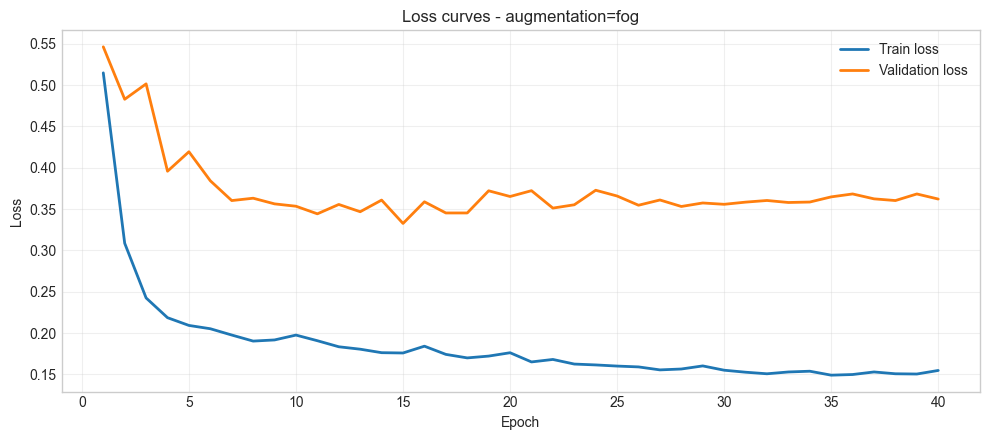

FoG-only augmentation metrics:
{'accuracy': 0.8530990727183992, 'precision': 0.6197530864197531, 'recall': 0.6306532663316583, 'f1': 0.6251556662515566, 'threshold': 0.4, 'epochs': 40, 'train_size': 6076, 'fog_rate_train': 0.4191902567478604, 'best_val_loss': 0.33269873623024016, 'best_epoch': 15, 'last_epoch': 40, 'train_loss_history': [0.5148886828046096, 0.3087342494412472, 0.24258012026548387, 0.2186859984931193, 0.20931383159599806, 0.20531029379681537, 0.197702210514169, 0.19037568028035917, 0.19176048628593745, 0.19764074079300228, 0.1908190737429418, 0.18349794737602534, 0.1805637455300281, 0.17634368303575013, 0.17597579767829494, 0.18421014053256887, 0.17428843567245886, 0.17002537697553635, 0.17222112056456115, 0.1762819736411697, 0.1651559718345341, 0.16815598316882785, 0.16258344116963838, 0.16152906449217547, 0.16015032310234872, 0.15913617250166442, 0.15552917522819418, 0.15659892621793245, 0.1603410432605367, 0.15514033915180908, 0.15271671881016932, 0.15081777439305658

In [362]:
# Step 2/3: FoG-only augmentation
metrics_fog = run_aug_experiment(mode='fog', plot_losses=True)
print('FoG-only augmentation metrics:')
print(metrics_fog)

In [363]:
# Comparison utility: best validation checkpoint vs last epoch checkpoint

def best_vs_last_table(metrics_dict, run_name='run'):
    rows = []

    # Backward compatibility: if detailed checkpoints are missing,
    # fallback to top-level metrics as best checkpoint values.
    best = metrics_dict.get('best_metrics')
    if best is None:
        best = {
            'accuracy': metrics_dict.get('accuracy', np.nan),
            'precision': metrics_dict.get('precision', np.nan),
            'recall': metrics_dict.get('recall', np.nan),
            'f1': metrics_dict.get('f1', np.nan)
        }

    last = metrics_dict.get('last_metrics')
    if last is None:
        last = {
            'accuracy': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan
        }

    rows.append({
        'run': run_name,
        'checkpoint': f"best_val (epoch {metrics_dict.get('best_epoch', 'NA')})",
        'accuracy': best.get('accuracy', np.nan),
        'precision': best.get('precision', np.nan),
        'recall': best.get('recall', np.nan),
        'f1': best.get('f1', np.nan)
    })
    rows.append({
        'run': run_name,
        'checkpoint': f"last (epoch {metrics_dict.get('last_epoch', 'NA')})",
        'accuracy': last.get('accuracy', np.nan),
        'precision': last.get('precision', np.nan),
        'recall': last.get('recall', np.nan),
        'f1': last.get('f1', np.nan)
    })

    return pd.DataFrame(rows)


In [388]:
# Example: display best vs last for runs already executed
frames = []

if 'metrics_global' in globals():
    frames.append(best_vs_last_table(metrics_global, run_name='global'))
if 'metrics_fog' in globals():
    frames.append(best_vs_last_table(metrics_fog, run_name='fog'))
if 'metrics_fog_hard' in globals():
    frames.append(best_vs_last_table(metrics_fog_hard, run_name='fog_hard'))

if frames:
    display(pd.concat(frames, ignore_index=True).round(4))
else:
    print('No metrics found yet. Run at least one augmentation experiment first.')


,run,checkpoint,accuracy,precision,recall,f1
0,global,best_val (epoch 13),0.8438,0.6005,0.5854,0.5929
1,global,last (epoch 40),0.8350,0.5781,0.5578,0.5678
2,fog,best_val (epoch 15),0.8531,0.6198,0.6307,0.6252
3,fog,last (epoch 40),0.8433,0.6000,0.5804,0.5900
4,fog_hard,best_val (epoch 24),0.8472,0.6076,0.6030,0.6053
5,fog_hard,last (epoch 40),0.8360,0.5871,0.5251,0.5544


Epoch 1/40
Epoch 2/40
Epoch 3/40
Epoch 4/40
Epoch 5/40
Epoch 6/40
Epoch 7/40
Epoch 8/40
Epoch 9/40
Epoch 10/40
Epoch 11/40
Epoch 12/40
Epoch 13/40
Epoch 14/40
Epoch 15/40
Epoch 16/40
Epoch 17/40
Epoch 18/40
Epoch 19/40
Epoch 20/40
Epoch 21/40
Epoch 22/40
Epoch 23/40
Epoch 24/40
Epoch 25/40
Epoch 26/40
Epoch 27/40
Epoch 28/40
Epoch 29/40
Epoch 30/40
Epoch 31/40
Epoch 32/40
Epoch 33/40
Epoch 34/40
Epoch 35/40
Epoch 36/40
Epoch 37/40
Epoch 38/40
Epoch 39/40
Epoch 40/40


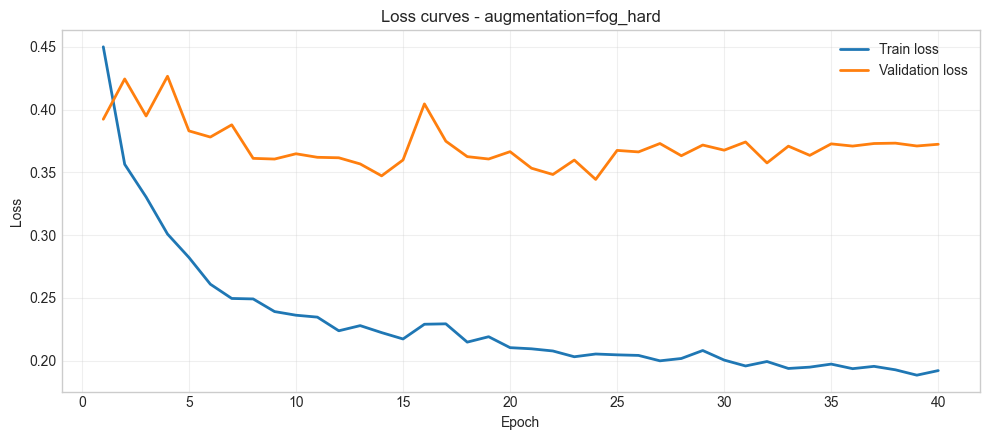

FoG + hard-activity augmentation metrics:
Activities used: [3]
{'accuracy': 0.8472425573450464, 'precision': 0.6075949367088608, 'recall': 0.6030150753768844, 'f1': 0.605296343001261, 'threshold': 0.4, 'epochs': 40, 'train_size': 4778, 'fog_rate_train': 0.2614064462118041, 'best_val_loss': 0.34442935215637965, 'best_epoch': 24, 'last_epoch': 40, 'train_loss_history': [0.45009800473848977, 0.35646355430285137, 0.3303725532690684, 0.300877005259196, 0.2822212002674739, 0.26092430889606477, 0.24954000850518546, 0.24916471580664318, 0.23909475485483805, 0.2361881250143051, 0.23466151644786198, 0.22377561966578166, 0.2278943016131719, 0.22233241905768714, 0.2172553728024165, 0.22899352838595707, 0.22932174344857534, 0.21473988314469655, 0.21904854277769725, 0.21033646047115326, 0.2094151066740354, 0.2076869253317515, 0.20308099071184793, 0.2052704005440076, 0.20460384448369345, 0.20414684603611627, 0.19983889460563659, 0.20170177112023036, 0.20805696765581766, 0.20043283333381018, 0.1957377

In [365]:
# Step 3/3: FoG + hard-activity augmentation

# On se concentre uniquement sur l'activité 3, car l'augmentation de l'activité 1 dégradait les scores.
selected_hard_activity_ids = [3]
if 'selected_hard_activity_ids' not in globals() or not selected_hard_activity_ids:
    raise ValueError("No hard activities selected. Set USER_HARD_ACTIVITY_IDS in the manual selection cell, or keep [] to use auto-detected activities.")
metrics_fog_hard = run_aug_experiment(mode='fog_hard', hard_activity_ids=selected_hard_activity_ids, plot_losses=True)
print('FoG + hard-activity augmentation metrics:')
print(f"Activities used: {selected_hard_activity_ids}")
print(metrics_fog_hard)

In [ ]:
# Threshold sweep + per-subject metrics (best checkpoint vs last checkpoint)

def threshold_sweep_table(metrics_dict, run_name='run', checkpoint='best',
                          thr_min=0.1, thr_max=0.9, n_points=33):
    key = 'best_eval' if checkpoint == 'best' else 'last_eval'
    if key not in metrics_dict:
        return pd.DataFrame([{
            'run': run_name,
            'checkpoint': checkpoint,
            'note': 'Missing rich eval payload. Re-run this experiment after re-executing the training function cell.'
        }])

    payload = metrics_dict[key]
    y_val = np.array(payload['val_true'], dtype=int)
    p_val = np.array(payload['val_prob'], dtype=float)
    y_test_local = np.array(payload['test_true'], dtype=int)
    p_test = np.array(payload['test_prob'], dtype=float)

    rows = []
    thresholds = np.linspace(thr_min, thr_max, n_points)
    for thr in thresholds:
        yv = (p_val > thr).astype(int)
        yt = (p_test > thr).astype(int)
        rows.append({
            'run': run_name,
            'checkpoint': checkpoint,
            'threshold': float(thr),
            'val_f1': f1_score(y_val, yv, zero_division=0),
            'test_f1': f1_score(y_test_local, yt, zero_division=0),
            'test_precision': precision_score(y_test_local, yt, zero_division=0),
            'test_recall': recall_score(y_test_local, yt, zero_division=0),
            'test_accuracy': accuracy_score(y_test_local, yt)
        })

    df = pd.DataFrame(rows)
    return df.sort_values(['val_f1', 'test_f1'], ascending=False).reset_index(drop=True)


def segment_data_with_subject_ids(df, subjects, w=2, o=0.75, fs=60):
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]

    y_local, subject_ids = [], []
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        data = sub_df[cols].values
        labels = sub_df['fog'].values

        for i in range(0, len(data) - win_size, step):
            y_local.append(pd.Series(labels[i:i + win_size]).mode()[0])
            subject_ids.append(sub)

    return np.array(y_local, dtype=int), np.array(subject_ids, dtype=int)


def per_subject_metrics(metrics_dict, run_name='run', checkpoint='best', threshold=None):
    key = 'best_eval' if checkpoint == 'best' else 'last_eval'
    if key not in metrics_dict:
        return pd.DataFrame([{
            'run': run_name,
            'checkpoint': checkpoint,
            'note': 'Missing rich eval payload. Re-run this experiment after re-executing the training function cell.'
        }])

    payload = metrics_dict[key]
    y_test_local = np.array(payload['test_true'], dtype=int)
    p_test = np.array(payload['test_prob'], dtype=float)

    if threshold is None:
        threshold = float(payload.get('best_threshold_from_val_f1', metrics_dict.get('threshold', 0.4)))

    y_test_reseg, test_subj_ids = segment_data_with_subject_ids(df_quat, test_subjects, w=2, o=0.75, fs=60)
    if len(y_test_reseg) != len(y_test_local) or not np.array_equal(y_test_reseg, y_test_local):
        return pd.DataFrame([{
            'run': run_name,
            'checkpoint': checkpoint,
            'note': 'Test alignment mismatch. Re-run segmentation and experiments in order.'
        }])

    y_pred = (p_test > threshold).astype(int)
    rows = []
    for sub in np.unique(test_subj_ids):
        idx = np.where(test_subj_ids == sub)[0]
        yt = y_test_local[idx]
        yp = y_pred[idx]
        rows.append({
            'run': run_name,
            'checkpoint': checkpoint,
            'subjectID': int(sub),
            'n_windows': int(len(idx)),
            'fog_rate_true': float(np.mean(yt)),
            'accuracy': accuracy_score(yt, yp),
            'precision': precision_score(yt, yp, zero_division=0),
            'recall': recall_score(yt, yp, zero_division=0),
            'f1': f1_score(yt, yp, zero_division=0),
            'threshold_used': float(threshold)
        })

    return pd.DataFrame(rows).sort_values('subjectID').reset_index(drop=True)


# Build concise summaries for all available runs
runs = {
    'global': globals().get('metrics_global', None),
    'fog': globals().get('metrics_fog', None),
    'fog_hard': globals().get('metrics_fog_hard', None)
}

sweep_top_rows = []
per_subject_frames = []

for run_name, m in runs.items():
    if m is None:
        continue

    # Top-1 threshold (on val F1) for each checkpoint
    for ck in ['best', 'last']:
        sweep_df = threshold_sweep_table(m, run_name=run_name, checkpoint=ck)
        if 'threshold' in sweep_df.columns:
            top = sweep_df.iloc[0]
            top['selected'] = 'top_by_val_f1'
            sweep_top_rows.append(top)

    # Subject-level table at tuned threshold (best val threshold of each checkpoint)
    for ck in ['best', 'last']:
        sub_df = per_subject_metrics(m, run_name=run_name, checkpoint=ck)
        per_subject_frames.append(sub_df)

if sweep_top_rows:
    print('Best threshold per run/checkpoint (selected by validation F1):')
    display(pd.DataFrame(sweep_top_rows).round(4))
else:
    print('No runs found for threshold sweep.')

if per_subject_frames:
    print('Per-subject metrics at tuned threshold (includes subject 20):')
    display(pd.concat(per_subject_frames, ignore_index=True).round(4))
else:
    print('No runs found for per-subject metrics.')


Best threshold per run/checkpoint (selected by validation F1):


,run,checkpoint,threshold,val_f1,test_f1,test_precision,test_recall,test_accuracy,selected
0,global,best,0.350,0.6034,0.6494,0.5874,0.7261,0.8477,top_by_val_f1
0,global,last,0.350,0.6008,0.6214,0.5732,0.6784,0.8394,top_by_val_f1
0,fog,best,0.300,0.6225,0.6717,0.5890,0.7814,0.8516,top_by_val_f1
0,fog,last,0.350,0.6317,0.6163,0.5736,0.6658,0.8389,top_by_val_f1
0,fog_hard,best,0.325,0.6420,0.6491,0.5590,0.7739,0.8375,top_by_val_f1
0,fog_hard,last,0.350,0.6271,0.6247,0.6028,0.6482,0.8487,top_by_val_f1


Per-subject metrics at tuned threshold (includes subject 20):


,run,checkpoint,subjectID,n_windows,fog_rate_true,accuracy,precision,recall,f1,threshold_used
0,global,best,4,536,0.0168,0.8358,0.0562,0.5556,0.1020,0.350
1,global,best,8,203,0.0000,0.8670,0.0000,0.0000,0.0000,0.350
2,global,best,9,493,0.0892,0.9108,0.5000,0.2727,0.3529,0.350
3,global,best,19,727,0.4539,0.7937,0.7679,0.7818,0.7748,0.350
4,global,best,22,90,0.1667,0.9667,0.8750,0.9333,0.9032,0.350
5,global,last,4,536,0.0168,0.8489,0.0500,0.4444,0.0899,0.350
6,global,last,8,203,0.0000,0.8670,0.0000,0.0000,0.0000,0.350
7,global,last,9,493,0.0892,0.9148,0.5385,0.3182,0.4000,0.350
8,global,last,19,727,0.4539,0.7593,0.7399,0.7242,0.7320,0.350
9,global,last,22,90,0.1667,0.9556,0.8667,0.8667,0.8667,0.350


,run,threshold,val_f1,test_f1,test_precision,test_recall
0,fog,0.300,0.6225,0.6717,0.5890,0.7814
1,global,0.350,0.6034,0.6494,0.5874,0.7261
2,fog_hard,0.325,0.6420,0.6491,0.5590,0.7739


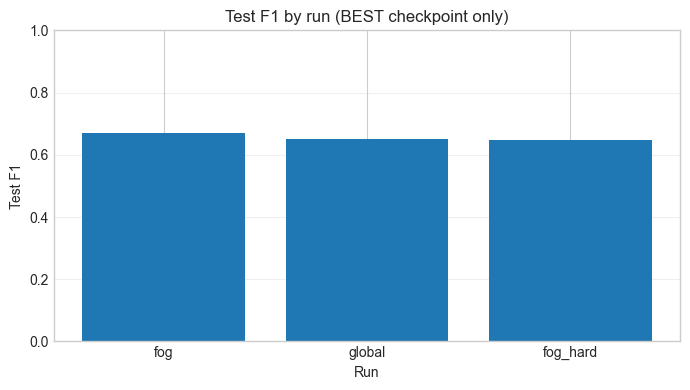

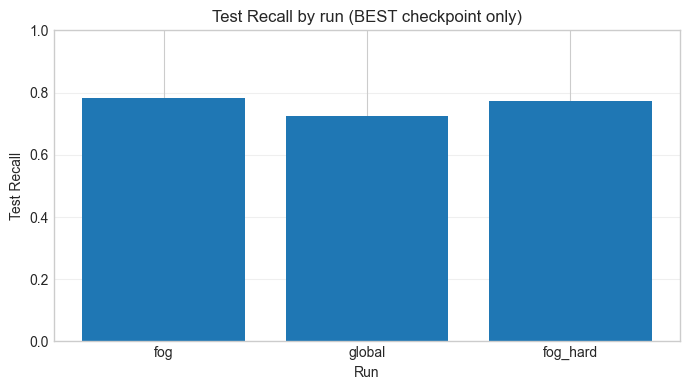

In [ ]:
# Plot only BEST checkpoint results (no last checkpoint)
import matplotlib.pyplot as plt

runs = {
    'global': globals().get('metrics_global', None),
    'fog': globals().get('metrics_fog', None),
    'fog_hard': globals().get('metrics_fog_hard', None)
}

best_rows = []
subject20_rows = []

for run_name, m in runs.items():
    if m is None:
        continue

    # Best threshold selected on validation F1 for BEST checkpoint only
    sweep_best = threshold_sweep_table(m, run_name=run_name, checkpoint='best')
    if 'threshold' in sweep_best.columns and len(sweep_best) > 0:
        top = sweep_best.iloc[0]
        best_rows.append({
            'run': run_name,
            'threshold': float(top['threshold']),
            'val_f1': float(top['val_f1']),
            'test_f1': float(top['test_f1']),
            'test_precision': float(top['test_precision']),
            'test_recall': float(top['test_recall'])
        })

        # Per-subject metrics at this selected threshold (BEST checkpoint only)
        sub_df = per_subject_metrics(m, run_name=run_name, checkpoint='best', threshold=float(top['threshold']))
        if 'subjectID' in sub_df.columns:
            sub20 = sub_df[sub_df['subjectID'] == 20]
            if len(sub20) > 0:
                subject20_rows.append({
                    'run': run_name,
                    'f1_subject20': float(sub20['f1'].iloc[0]),
                    'recall_subject20': float(sub20['recall'].iloc[0]),
                    'precision_subject20': float(sub20['precision'].iloc[0])
                })

if best_rows:
    best_df = pd.DataFrame(best_rows).sort_values('test_f1', ascending=False).reset_index(drop=True)
    display(best_df.round(4))

    plt.figure(figsize=(7, 4))
    plt.bar(best_df['run'], best_df['test_f1'])
    plt.title('Test F1 by run (BEST checkpoint only)')
    plt.xlabel('Run')
    plt.ylabel('Test F1')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(best_df['run'], best_df['test_recall'])
    plt.title('Test Recall by run (BEST checkpoint only)')
    plt.xlabel('Run')
    plt.ylabel('Test Recall')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print('No available runs to plot. Run global/fog/fog_hard first.')

if subject20_rows:
    s20_df = pd.DataFrame(subject20_rows).sort_values('f1_subject20', ascending=False).reset_index(drop=True)
    display(s20_df.round(4))

    plt.figure(figsize=(7, 4))
    plt.bar(s20_df['run'], s20_df['f1_subject20'])
    plt.title('Subject 20 F1 by run (BEST checkpoint only)')
    plt.xlabel('Run')
    plt.ylabel('F1 (subject 20)')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


,run,auc_roc_test_best
0,fog,0.8945
1,fog_hard,0.8901
2,global,0.8839


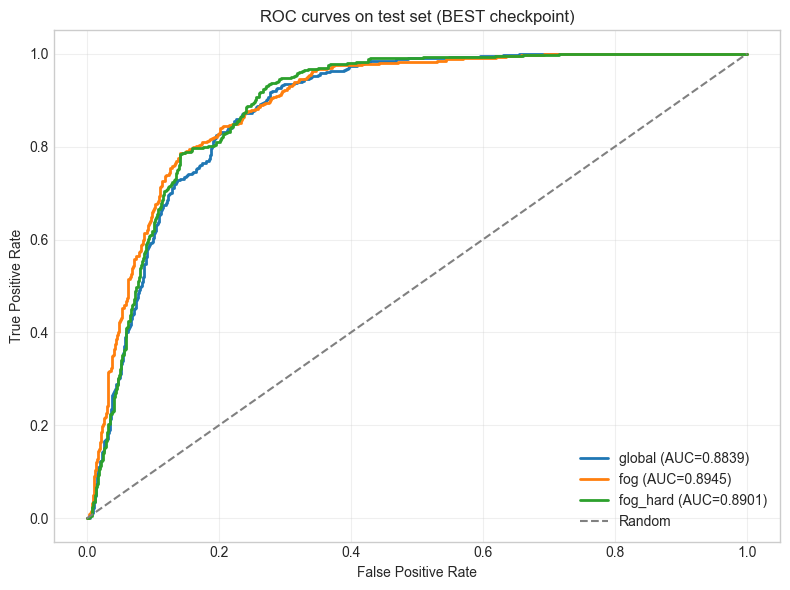

In [366]:
# AUC-ROC from stored probabilities (BEST checkpoint only)
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

runs = {
    'global': globals().get('metrics_global', None),
    'fog': globals().get('metrics_fog', None),
    'fog_hard': globals().get('metrics_fog_hard', None)
}

auc_rows = []
plt.figure(figsize=(8, 6))

for run_name, m in runs.items():
    if m is None or 'best_eval' not in m:
        continue

    y_true = np.array(m['best_eval']['test_true'], dtype=int)
    y_prob = np.array(m['best_eval']['test_prob'], dtype=float)

    # AUC-ROC is threshold-independent and uses probabilities directly
    auc_val = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    auc_rows.append({'run': run_name, 'auc_roc_test_best': auc_val})
    plt.plot(fpr, tpr, linewidth=2, label=f"{run_name} (AUC={auc_val:.4f})")

if auc_rows:
    auc_df = pd.DataFrame(auc_rows).sort_values('auc_roc_test_best', ascending=False).reset_index(drop=True)
    display(auc_df.round(4))

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves on test set (BEST checkpoint)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No compatible run found. Re-run Cells 14, 15, and 18 first.')


In [367]:
def per_subject_metrics(metrics_run, df_quat_in, subjects_list_in, threshold):
    """Calculate metrics for each subject in the test set."""
    
    # Regenerate the subject IDs for each window to ensure alignment
    _, subjects_per_window = segment_data_with_subject_ids(df_quat_in, subjects_list_in)
    
    # Use the 'best' model checkpoint for evaluation
    y_true = np.array(metrics_run['best_eval']['test_true'])
    y_prob = np.array(metrics_run['best_eval']['test_prob'])
    
    # --- VALIDATION CHECK ---
    if len(y_true) != len(subjects_per_window):
        print(f"Error: Length mismatch! Predictions length: {len(y_true)}, Subjects per window: {len(subjects_per_window)}")
        print("This might happen if segmentation parameters have changed. Please re-run experiments.")
        return pd.DataFrame()
    # --- END VALIDATION ---

    y_pred = (y_prob > threshold).astype(int)

    # Create a DataFrame to align predictions with subjects
    results_df = pd.DataFrame({
        'subject': subjects_per_window,
        'y_true': y_true,
        'y_pred': y_pred
    })

    # Calculate metrics per subject
    subject_stats = []
    for subject_id in sorted(results_df['subject'].unique()):
        sub_df = results_df[results_df['subject'] == subject_id]
        
        # Check if the subject has any true FoG events
        has_fog = sub_df['y_true'].sum() > 0
        
        f1 = f1_score(sub_df['y_true'], sub_df['y_pred'], zero_division=0)
        precision = precision_score(sub_df['y_true'], sub_df['y_pred'], zero_division=0)
        recall = recall_score(sub_df['y_true'], sub_df['y_pred'], zero_division=0)
        accruracy = accuracy_score(sub_df['y_true'], sub_df['y_pred'])
        subject_stats.append({
            'Subject': subject_id,
            'F1 Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Num Samples': len(sub_df),
            'Accuracy': accruracy,
            'FoG Samples': sub_df['y_true'].sum(),
            'Has FoG': has_fog
        })
        
    return pd.DataFrame(subject_stats)

# --- Evaluation for 'fog_hard' with threshold = 0.4 ---
# We now pass the dataframe and the list of subjects to the function
fog_hard_per_subject_df = per_subject_metrics(metrics_fog, df_quat, test_subjects, threshold=0.4)

print("Per-Subject Performance for 'fog_hard' (Threshold = 0.4)")
display(fog_hard_per_subject_df.round(3))


Per-Subject Performance for 'fog_hard' (Threshold = 0.4)


,Subject,F1 Score,Precision,Recall,Num Samples,Accuracy,FoG Samples,Has FoG
0,4,0.132,0.075,0.556,536,0.877,9,True
1,8,0.000,0.000,0.000,203,0.897,0,False
2,9,0.241,0.500,0.159,493,0.911,44,True
3,19,0.740,0.788,0.697,727,0.777,330,True
4,22,0.692,0.818,0.600,90,0.911,15,True


In [400]:
def per_activity_metrics(metrics_run, df_quat_in, subjects_list_in, threshold):
    """Calculate metrics for each activity in the test set."""
    
    # Regenerate activity IDs for each window to ensure alignment
    _, y_true_reseg, activities_per_window, _ = segment_data_with_activity_local(df_quat_in, subjects_list_in)
    
    if activities_per_window is None:
        print("Error: Could not retrieve activity labels. Check column names in the dataframe.")
        return pd.DataFrame()

    # Use the 'best' model checkpoint for evaluation
    y_true_from_run = np.array(metrics_run['best_eval']['test_true'])
    y_prob = np.array(metrics_run['best_eval']['test_prob'])
    
    # --- VALIDATION CHECK ---
    if len(y_true_from_run) != len(activities_per_window):
        print(f"Error: Length mismatch! Predictions length: {len(y_true_from_run)}, Activities per window: {len(activities_per_window)}")
        print("This might happen if segmentation parameters have changed. Please re-run experiments.")
        return pd.DataFrame()
    # --- END VALIDATION ---

    y_pred = (y_prob > threshold).astype(int)

    # Create a DataFrame to align predictions with activities
    results_df = pd.DataFrame({
        'activity': activities_per_window,
        'y_true': y_true_from_run,
        'y_pred': y_pred
    })

    # Calculate metrics per activity
    activity_stats = []
    for activity_id in sorted(results_df['activity'].unique()):
        act_df = results_df[results_df['activity'] == activity_id]
        
        f1 = f1_score(act_df['y_true'], act_df['y_pred'], zero_division=0)
        precision = precision_score(act_df['y_true'], act_df['y_pred'], zero_division=0)
        recall = recall_score(act_df['y_true'], act_df['y_pred'], zero_division=0)
        accuracy = accuracy_score(act_df['y_true'], act_df['y_pred'])
        activity_stats.append({
            'ActivityID': activity_id,
            'F1 Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Accuracy': accuracy,
            'Num Samples': len(act_df),
            'FoG Samples': act_df['y_true'].sum()
        })
        
    return pd.DataFrame(activity_stats)

# --- Evaluation for 'fog_hard' with threshold = 0.4 ---
# We pass the dataframe and the list of subjects to the function
fog_hard_per_activity_df = per_activity_metrics(metrics_fog, df_quat, test_subjects, threshold=0.4)

print("Per-Activity Performance for 'fog_hard' (Threshold = 0.4)")
display(fog_hard_per_activity_df.round(3))


Per-Activity Performance for 'fog_hard' (Threshold = 0.4)


,ActivityID,F1 Score,Precision,Recall,Accuracy,Num Samples,FoG Samples
0,0,0.000,0.000,0.000,1.000,41,0
1,1,0.194,0.462,0.122,0.942,865,49
2,2,0.000,0.000,0.000,0.975,79,0
3,3,0.097,0.051,1.000,0.822,315,3
4,4,0.000,0.000,0.000,0.980,50,0
5,5,0.000,0.000,0.000,0.918,49,0
6,6,0.708,0.655,0.771,0.761,255,96
7,7,0.726,0.789,0.672,0.678,395,250


In [ ]:
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_model_by_activity(model_path, df_quat_in, subjects_list_in, threshold=0.4):
    """
    Loads a pre-trained model, evaluates it, and computes metrics per activity.
    """
    # --- 1. Load Data and Model ---
    # Ensure data is segmented in the same way as for other tests
    X_test_local, y_true_local, activities_per_window, _ = segment_data_with_activity_local(df_quat_in, subjects_list_in)
    
    if activities_per_window is None:
        print("Error: Could not retrieve activity labels.")
        return pd.DataFrame()

    # Load the model state
    try:
        model_state = torch.load(model_path, map_location=device)
        model = MultiBranchCNN() # Assumes the same architecture
        model.load_state_dict(model_state)
        model.to(device)
        model.eval()
        print(f"Successfully loaded model from: {model_path}")
    except Exception as e:
        print(f"Error loading model: {e}")
        return pd.DataFrame()

    # --- 2. Get Predictions ---
    test_ds_local = FogDataset(X_test_local, y_true_local)
    test_ld_local = torch.utils.data.DataLoader(test_ds_local, batch_size=64, shuffle=False)
    
    all_probs = []
    with torch.no_grad():
        for inputs, _ in test_ld_local:
            inputs = inputs.to(device)
            probs = model(inputs).squeeze()
            if probs.dim() == 0:
                probs = probs.unsqueeze(0)
            all_probs.extend(probs.cpu().numpy().tolist())
    
    y_prob = np.array(all_probs)
    y_pred = (y_prob > threshold).astype(int)

    # --- 3. Calculate Metrics per Activity ---
    results_df = pd.DataFrame({
        'activity': activities_per_window,
        'y_true': y_true_local,
        'y_pred': y_pred
    })

    activity_stats = []
    for activity_id in sorted(results_df['activity'].unique()):
        act_df = results_df[results_df['activity'] == activity_id]
        
        activity_stats.append({
            'ActivityID': activity_id,
            'F1 Score': f1_score(act_df['y_true'], act_df['y_pred'], zero_division=0),
            'Precision': precision_score(act_df['y_true'], act_df['y_pred'], zero_division=0),
            'Recall': recall_score(act_df['y_true'], act_df['y_pred'], zero_division=0),
            'Accuracy': accuracy_score(act_df['y_true'], act_df['y_pred']),
            'Num Samples': len(act_df),
            'FoG Samples': act_df['y_true'].sum()
        })
        
    return pd.DataFrame(activity_stats)

# --- Run Evaluation on the Pre-trained Model ---
model_file = 'best_multibranch_model_new_split_2.pth'
baseline_activity_df = evaluate_model_by_activity(model_file, df_quat, test_subjects, threshold=0.4)

print(f"\nPer-Activity Performance for Baseline Model '{model_file}' (Threshold = 0.4)")
display(baseline_activity_df.round(3))

Successfully loaded model from: best_multibranch_model_new_split_2.pth

Per-Activity Performance for Baseline Model 'best_multibranch_model_new_split_2.pth' (Threshold = 0.4)


,ActivityID,F1 Score,Precision,Recall,Num Samples,FoG Samples
0,0,0.000,0.000,0.000,41,0
1,1,0.212,0.412,0.143,865,49
2,2,0.000,0.000,0.000,79,0
3,3,0.100,0.053,1.000,315,3
4,4,0.000,0.000,0.000,50,0
5,5,0.000,0.000,0.000,49,0
6,6,0.683,0.634,0.740,255,96
7,7,0.716,0.761,0.676,395,250


In [399]:
df_quat = pd.read_csv('sensor_data_quaternions.csv')

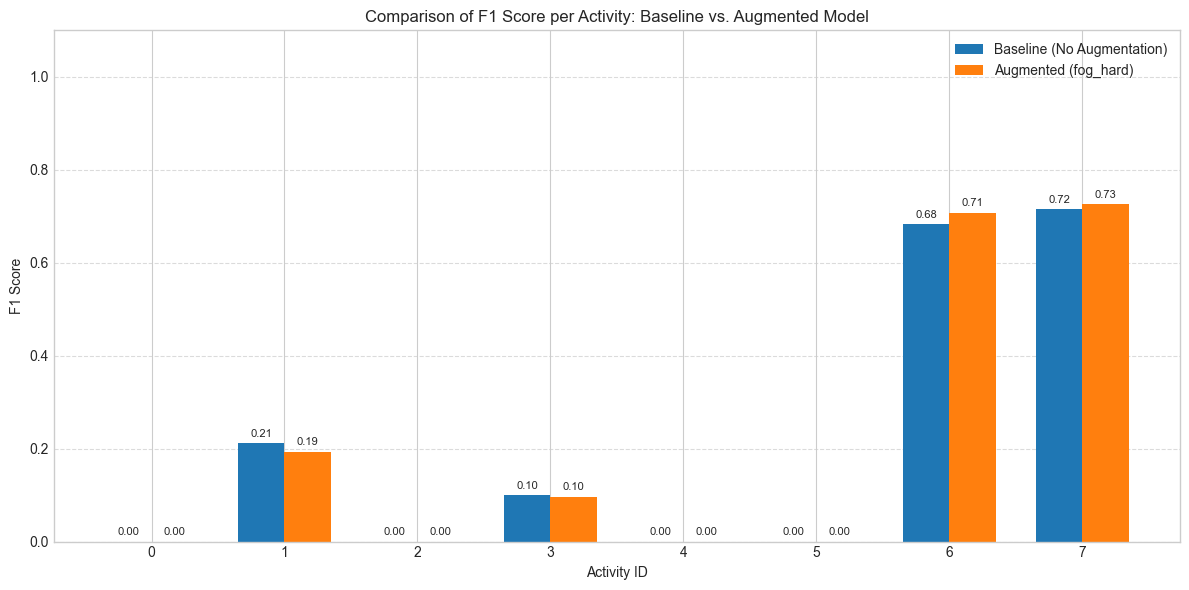

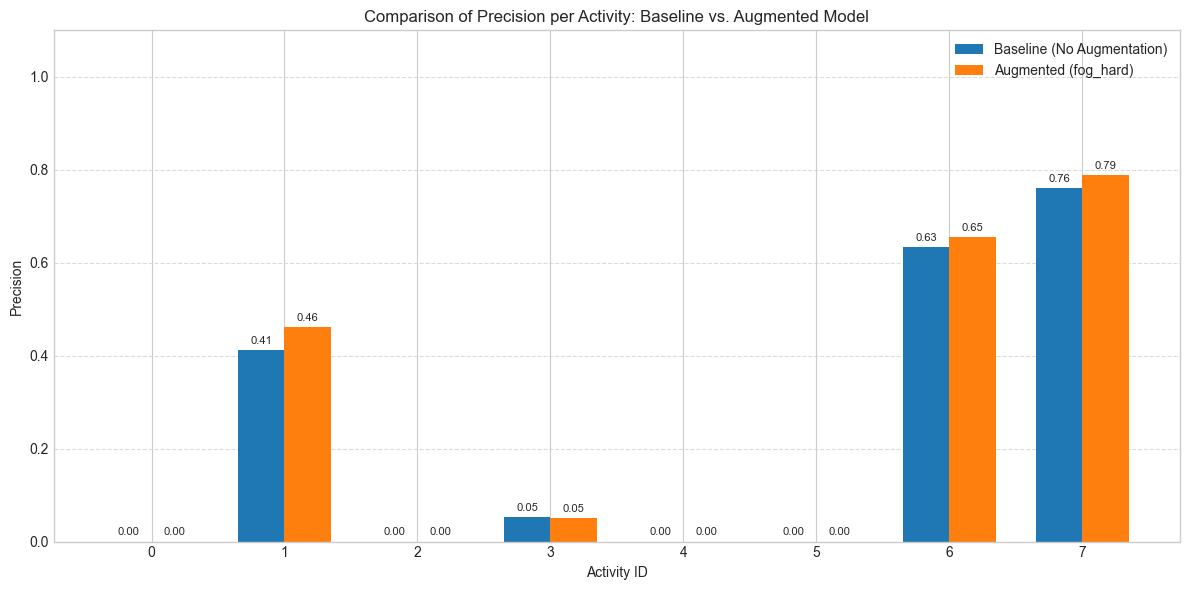

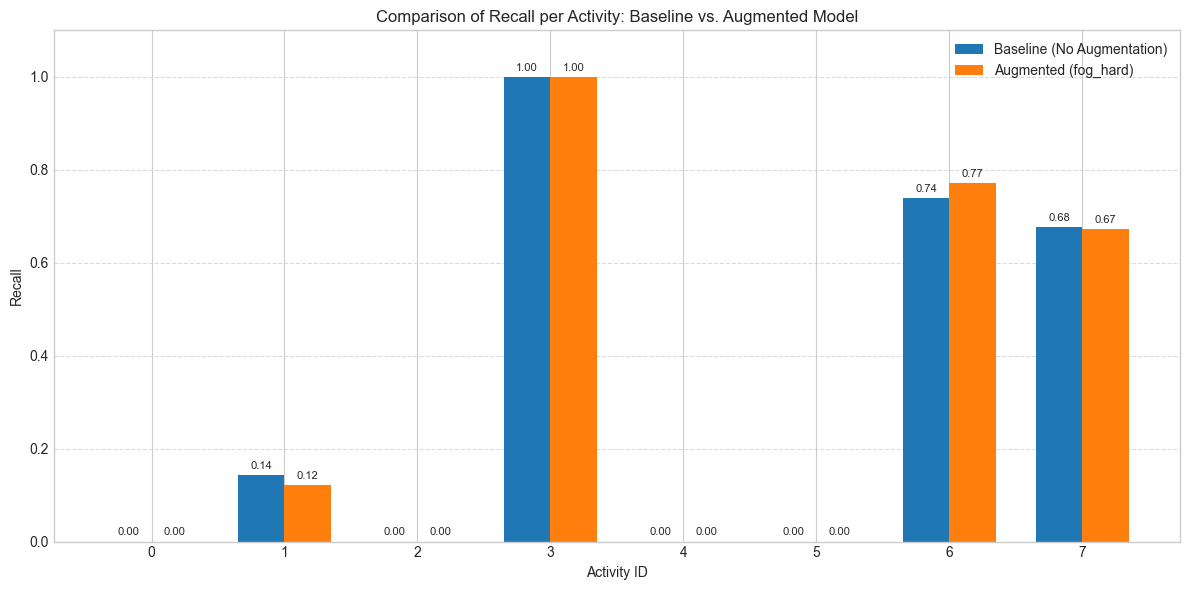

Data used for the plots:


,ActivityID,F1 Score_baseline,Precision_baseline,Recall_baseline,F1 Score_augmented,Precision_augmented,Recall_augmented
0,0,0.000,0.000,0.000,0.000,0.000,0.000
1,1,0.212,0.412,0.143,0.194,0.462,0.122
2,2,0.000,0.000,0.000,0.000,0.000,0.000
3,3,0.100,0.053,1.000,0.097,0.051,1.000
4,4,0.000,0.000,0.000,0.000,0.000,0.000
5,5,0.000,0.000,0.000,0.000,0.000,0.000
6,6,0.683,0.634,0.740,0.708,0.655,0.771
7,7,0.716,0.761,0.676,0.726,0.789,0.672


In [407]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_comparison(comparison_df, metric_name):
    """Helper function to plot a comparison for a given metric (F1 Score, Precision, or Recall)."""
    
    activity_ids = comparison_df['ActivityID']
    x = np.arange(len(activity_ids))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Bars for the baseline model
    rects1 = ax.bar(x - width/2, comparison_df[f'{metric_name}_baseline'], width, label='Baseline (No Augmentation)')
    
    # Bars for the augmented model
    rects2 = ax.bar(x + width/2, comparison_df[f'{metric_name}_augmented'], width, label='Augmented (fog_hard)')

    # --- Add labels, title, and legend ---
    ax.set_ylabel(metric_name)
    ax.set_title(f'Comparison of {metric_name} per Activity: Baseline vs. Augmented Model')
    ax.set_xticks(x)
    ax.set_xticklabels(activity_ids)
    ax.set_xlabel('Activity ID')
    ax.legend()
    
    ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=8)
    ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=8)
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.1) # Leave some space for labels above bars

    fig.tight_layout()
    plt.show()

# Check if both dataframes exist before plotting
if 'baseline_activity_df' in globals() and 'fog_hard_per_activity_df' in globals():
    
    # --- Data Preparation ---
    metrics_to_compare = ['F1 Score', 'Precision', 'Recall']
    
    # Merge the two dataframes on ActivityID for direct comparison
    comparison_df = pd.merge(
        baseline_activity_df[['ActivityID'] + metrics_to_compare],
        fog_hard_per_activity_df[['ActivityID'] + metrics_to_compare],
        on='ActivityID',
        suffixes=('_baseline', '_augmented')
    )

    # --- Plotting ---
    for metric in metrics_to_compare:
        plot_metric_comparison(comparison_df, metric)
    
    # Display the merged data table for clarity
    print("Data used for the plots:")
    display(comparison_df.round(3))

else:
    print("Could not generate plot. Please ensure that both the baseline and augmented per-activity evaluations have been run successfully.")


In [402]:
import pandas as pd

# A list of the metrics dictionaries for the runs we are interested in
runs_to_display = {
    'global': globals().get('metrics_global'),
    'fog': globals().get('metrics_fog'),
    'fog_hard': globals().get('metrics_fog_hard')
}

# We will store the results in this list
results_at_fixed_threshold = []

print("Performance Metrics at a Fixed Threshold of 0.4 (using 'best' checkpoint)")

# Iterate over the runs
for run_name, metrics in runs_to_display.items():
    if metrics and 'best_eval' in metrics and 'metrics_at_input_threshold' in metrics['best_eval']:
        # The 'metrics_at_input_threshold' dictionary already contains the metrics
        # calculated with the threshold passed to the training function (which was 0.4)
        fixed_metrics = metrics['best_eval']['metrics_at_input_threshold']
        
        results_at_fixed_threshold.append({
            'Model': run_name,
            'F1 Score': fixed_metrics.get('f1'),
            'Precision': fixed_metrics.get('precision'),
            'Recall': fixed_metrics.get('recall'),
            'Accuracy': fixed_metrics.get('accuracy'),
            'Threshold': 0.4
        })
    else:
        # Handle case where metrics are not available
        results_at_fixed_threshold.append({
            'Model': run_name,
            'F1 Score': 'N/A',
            'Precision': 'N/A',
            'Recall': 'N/A',
            'Accuracy': 'N/A',
            'Threshold': 0.4
        })

# Create and display the DataFrame
results_df = pd.DataFrame(results_at_fixed_threshold)
display(results_df)


Performance Metrics at a Fixed Threshold of 0.4 (using 'best' checkpoint)


,Model,F1 Score,Precision,Recall,Accuracy,Threshold
0,global,0.592875,0.600515,0.585427,0.843826,0.4
1,fog,0.625156,0.619753,0.630653,0.853099,0.4
2,fog_hard,0.605296,0.607595,0.603015,0.847243,0.4


## Analysis

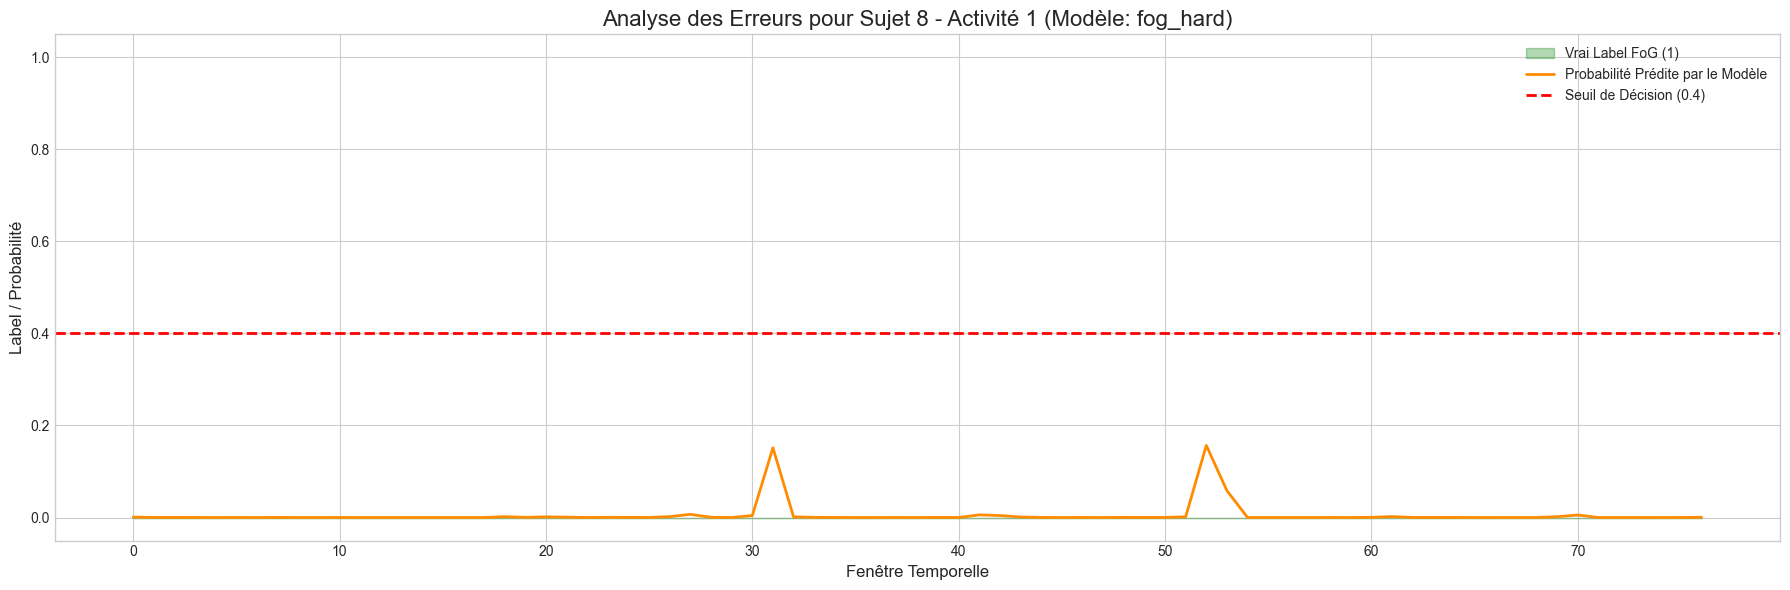

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def segment_data_for_error_analysis(df, subjects, w=2, o=0.75, fs=60):
    """
    Segments data and returns windows, labels, subject IDs, and activity IDs for detailed analysis.
    """
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    activity_col = 'activity' # Assuming this column exists
    if activity_col not in df.columns:
        print(f"Error: '{activity_col}' column not found in DataFrame.")
        return None, None, None, None

    X, y, subject_ids, activity_ids = [], [], [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        if sub_df.empty:
            continue
            
        data = sub_df[cols].values
        labels = sub_df['fog'].values
        acts = sub_df[activity_col].values
        
        for i in range(0, len(data) - win_size, step):
            window = data[i:i + win_size]
            window_rel = window - window[0]
            
            X.append(window_rel)
            y.append(pd.Series(labels[i:i + win_size]).mode()[0])
            subject_ids.append(sub)
            activity_ids.append(pd.Series(acts[i:i + win_size]).mode()[0])
            
    return np.array(X), np.array(y), np.array(subject_ids, dtype=int), np.array(activity_ids, dtype=int)

def plot_subject_activity_predictions(metrics_run, df_quat_in, subjects_list_in, subject_to_plot, activity_to_plot, threshold=0.4):
    """
    Plots the model's predictions vs. true labels for a specific subject and activity.
    """
    if not metrics_run or 'best_eval' not in metrics_run:
        print("Error: 'metrics_fog_hard' is not defined or is missing 'best_eval'. Please run the experiment cell first.")
        return

    # 1. Get all predictions and true labels from the run
    y_true_full = np.array(metrics_run['best_eval']['test_true'])
    y_prob_full = np.array(metrics_run['best_eval']['test_prob'])
    
    # 2. Get the subject and activity ID for each window in the test set
    _, _, subject_ids_full, activity_ids_full = segment_data_for_error_analysis(df_quat_in, subjects_list_in)
    
    if subject_ids_full is None:
        return # Error already printed in the segmentation function

    # 3. Create a DataFrame for easy filtering
    analysis_df = pd.DataFrame({
        'subject': subject_ids_full,
        'activity': activity_ids_full,
        'y_true': y_true_full,
        'y_prob': y_prob_full
    })

    # 4. Filter for the specific subject and activity
    plot_df = analysis_df[(analysis_df['subject'] == subject_to_plot) & (analysis_df['activity'] == activity_to_plot)]
    
    if plot_df.empty:
        print(f"No data found for Subject {subject_to_plot}, Activity {activity_to_plot} in the test set.")
        return

    # 5. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 6))
    
    time_steps = np.arange(len(plot_df))
    
    # Plot True Labels as a filled area
    ax.fill_between(time_steps, plot_df['y_true'], step="pre", alpha=0.3, label='Vrai Label FoG (1)', color='green')
    
    # Plot Model's Predicted Probability
    ax.plot(time_steps, plot_df['y_prob'], label='Probabilité Prédite par le Modèle', color='darkorange', linewidth=2)
    
    # Plot the decision threshold
    ax.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Seuil de Décision ({threshold})')
    
    # Highlight False Positives and False Negatives
    y_pred = (plot_df['y_prob'] > threshold).astype(int)
    fp_mask = (plot_df['y_true'] == 0) & (y_pred == 1)
    fn_mask = (plot_df['y_true'] == 1) & (y_pred == 0)
    
    if fp_mask.any():
        ax.plot(time_steps[fp_mask], plot_df['y_prob'][fp_mask], 'x', color='red', markersize=8, label='Faux Positif')
    if fn_mask.any():
        ax.plot(time_steps[fn_mask], plot_df['y_prob'][fn_mask], 'o', markerfacecolor='none', markeredgecolor='blue', markersize=8, label='Faux Négatif')

    ax.set_title(f'Analyse des Erreurs pour Sujet {subject_to_plot} - Activité {activity_to_plot} (Modèle: fog_hard)', fontsize=16)
    ax.set_xlabel('Fenêtre Temporelle', fontsize=12)
    ax.set_ylabel('Label / Probabilité', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()


SUBJECT_TO_PLOT = 8
ACTIVITY_TO_PLOT = 1
THRESHOLD = 0.4 # Utilisez le seuil avec lequel vous évaluez habituellement

# Assurez-vous que la variable `metrics_fog_hard` existe
if 'metrics_fog' in globals():
    plot_subject_activity_predictions(
        metrics_fog, 
        df_quat, 
        test_subjects, 
        subject_to_plot=SUBJECT_TO_PLOT, 
        activity_to_plot=ACTIVITY_TO_PLOT, 
        threshold=THRESHOLD
    )
else:
    print("Veuillez d'abord exécuter la cellule d'entraînement pour 'fog_hard' (cellule 20) pour générer les métriques.")


In [408]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

def find_best_thresholds_per_activity(metrics_run, df_quat_in, subjects_list_in):
    """
    Finds the best F1-score threshold for each activity using the validation set.
    """
    if not metrics_run or 'best_eval' not in metrics_run:
        print("Metrics not found. Please run the experiment first.")
        return None

    # 1. Get validation set predictions and true labels
    y_true_val = np.array(metrics_run['best_eval']['val_true'])
    y_prob_val = np.array(metrics_run['best_eval']['val_prob'])
    
    # 2. Get activity IDs for the validation set
    _, _, activity_ids_val, _ = segment_data_with_activity_local(df_quat_in, subjects_list_in)
    
    if activity_ids_val is None:
        return None

    # 3. Create a DataFrame for analysis
    val_df = pd.DataFrame({
        'activity': activity_ids_val,
        'y_true': y_true_val,
        'y_prob': y_prob_val
    })

    best_thresholds = {}
    threshold_candidates = np.linspace(0.05, 0.95, 100)

    # 4. Iterate over each activity present in the validation set
    for activity_id in sorted(val_df['activity'].unique()):
        act_df = val_df[val_df['activity'] == activity_id]
        
        if act_df.empty or act_df['y_true'].sum() == 0:
            # If no FoG samples for this activity, use a default threshold
            best_thresholds[activity_id] = 0.5
            continue

        best_f1 = -1
        best_thr = 0.5
        for thr in threshold_candidates:
            y_pred = (act_df['y_prob'] > thr).astype(int)
            f1 = f1_score(act_df['y_true'], y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        
        best_thresholds[activity_id] = best_thr
        
    return best_thresholds

def evaluate_with_activity_specific_thresholds(metrics_run, df_quat_in, test_subjects_in, activity_thresholds):
    """
    Evaluates the test set using a dictionary of activity-specific thresholds.
    """
    if not metrics_run or 'best_eval' not in metrics_run:
        print("Metrics not found.")
        return None

    # 1. Get test set predictions and true labels
    y_true_test = np.array(metrics_run['best_eval']['test_true'])
    y_prob_test = np.array(metrics_run['best_eval']['test_prob'])
    
    # 2. Get activity IDs for the test set
    _, _, activity_ids_test, _ = segment_data_with_activity_local(df_quat_in, test_subjects_in)
    
    if activity_ids_test is None:
        return None

    # 3. Apply activity-specific thresholds
    y_pred_specific = np.zeros_like(y_true_test)
    default_threshold = np.mean(list(activity_thresholds.values())) # Fallback for unseen activities

    for i in range(len(y_true_test)):
        activity_id = activity_ids_test[i]
        threshold = activity_thresholds.get(activity_id, default_threshold)
        y_pred_specific[i] = 1 if y_prob_test[i] > threshold else 0

    # 4. Calculate overall metrics with the new prediction method
    specific_metrics = {
        'F1 Score': f1_score(y_true_test, y_pred_specific, zero_division=0),
        'Precision': precision_score(y_true_test, y_pred_specific, zero_division=0),
        'Recall': recall_score(y_true_test, y_pred_specific, zero_division=0)
    }
    
    # 5. For comparison, get metrics with a single, fixed threshold
    fixed_threshold = 0.4
    y_pred_fixed = (y_prob_test > fixed_threshold).astype(int)
    fixed_metrics = {
        'F1 Score': f1_score(y_true_test, y_pred_fixed, zero_division=0),
        'Precision': precision_score(y_true_test, y_pred_fixed, zero_division=0),
        'Recall': recall_score(y_true_test, y_pred_fixed, zero_division=0)
    }

    # 6. Create a comparison DataFrame
    comparison_data = {
        'Metric': ['F1 Score', 'Precision', 'Recall'],
        'Avant (Seuil Fixe = 0.4)': [fixed_metrics['F1 Score'], fixed_metrics['Precision'], fixed_metrics['Recall']],
        'Après (Seuils par Activité)': [specific_metrics['F1 Score'], specific_metrics['Precision'], specific_metrics['Recall']]
    }
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df['Amélioration'] = comparison_df['Après (Seuils par Activité)'] - comparison_df['Avant (Seuil Fixe = 0.4)']
    
    return comparison_df, activity_thresholds


# --- Exécution ---
if 'metrics_fog' in globals():
    # 1. Find best thresholds on the validation set
    # Note: We pass `val_subjects` here
    print("Recherche des meilleurs seuils sur le set de validation...")
    best_thresholds = find_best_thresholds_per_activity(metrics_fog, df_quat, val_subjects)
    
    if best_thresholds:
        print("Seuils optimaux trouvés par activité :")
        # Pretty print the dictionary
        for activity, threshold in best_thresholds.items():
            print(f"  - Activité {activity}: {threshold:.2f}")

        # 2. Evaluate on the test set using these new thresholds
        # Note: We pass `test_subjects` here
        print("\nÉvaluation sur le set de test avec les seuils spécifiques...")
        comparison_results_df, _ = evaluate_with_activity_specific_thresholds(metrics_fog, df_quat, test_subjects, best_thresholds)
        
        display(comparison_results_df.round(4))
else:
    print("Veuillez d'abord exécuter la cellule d'entraînement pour 'fog_hard' (cellule 20) pour générer les métriques.")


Recherche des meilleurs seuils sur le set de validation...
Seuils optimaux trouvés par activité :
  - Activité 1: 0.10
  - Activité 2: 0.50
  - Activité 3: 0.90
  - Activité 4: 0.50
  - Activité 5: 0.05
  - Activité 6: 0.11
  - Activité 7: 0.23

Évaluation sur le set de test avec les seuils spécifiques...


,Metric,Avant (Seuil Fixe = 0.4),Après (Seuils par Activité),Amélioration
0,F1 Score,0.6252,0.7354,0.1103
1,Precision,0.6198,0.6281,0.0084
2,Recall,0.6307,0.8869,0.2563


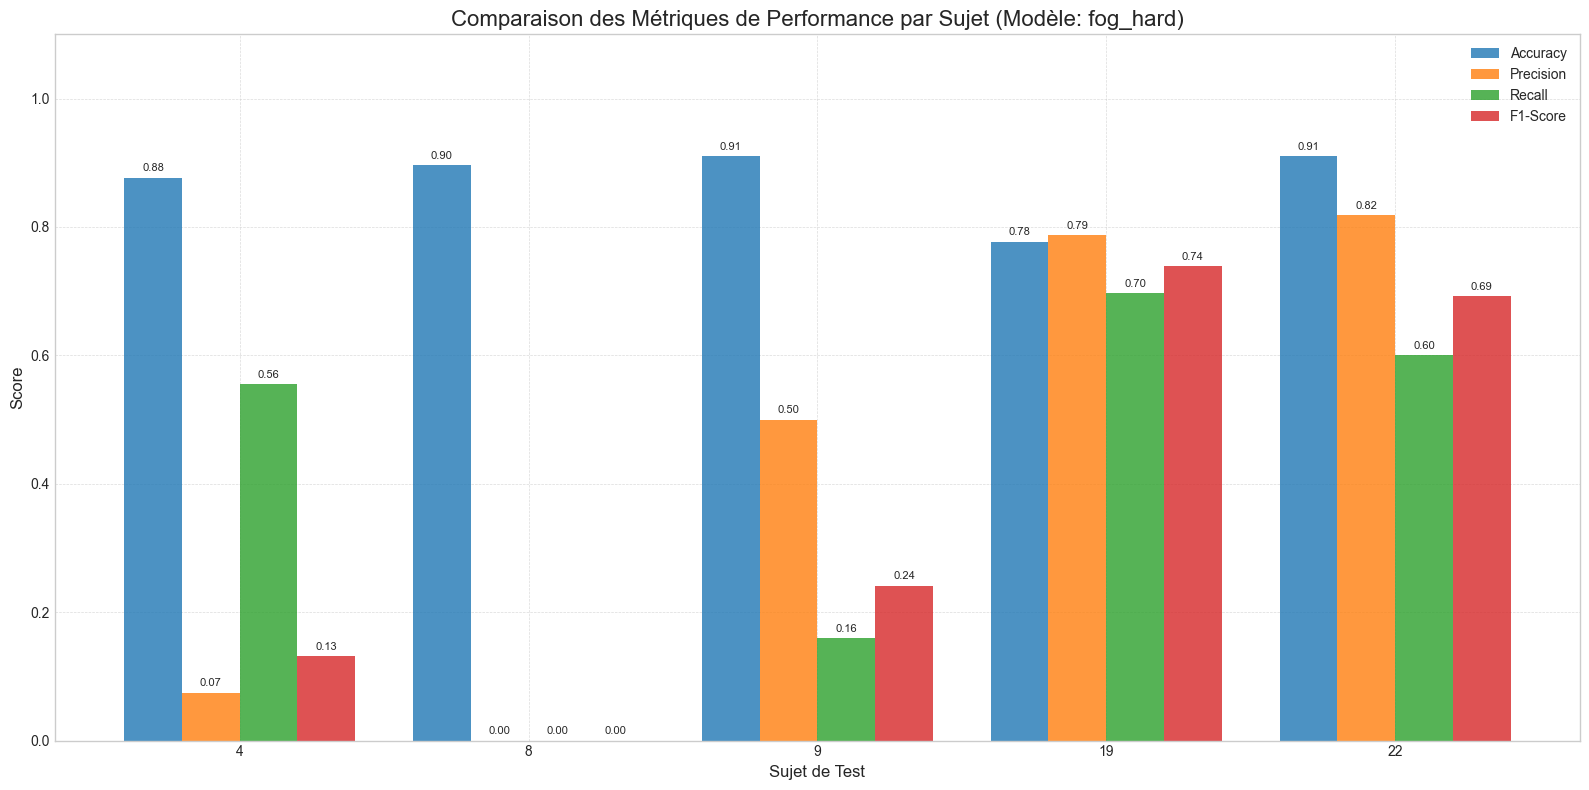

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


results_df = fog_hard_per_subject_df.rename(columns={
    'F1 Score': 'F1-Score',
    'Subject': 'Subject'
})

    # --- Création du graphique ---
fig, ax = plt.subplots(figsize=(16, 8))

subjects = results_df['Subject'].astype(str)
x = np.arange(len(subjects))  # les positions des labels sur l'axe x
width = 0.2  # la largeur des barres

    # Création des barres pour chaque métrique
rects1 = ax.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
rects2 = ax.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', alpha=0.8)
rects3 = ax.bar(x + 0.5*width, results_df['Recall'], width, label='Recall', alpha=0.8)
rects4 = ax.bar(x + 1.5*width, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)

    # Ajout des textes, titres et légendes
ax.set_xlabel('Sujet de Test', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Métriques de Performance par Sujet (Modèle: fog_hard)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_ylim(0, 1.1) # Laisse de l'espace pour les étiquettes au-dessus des barres

    # Ajout des étiquettes de valeur sur chaque barre
ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=8)
ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=8)
ax.bar_label(rects3, padding=3, fmt='%.2f', fontsize=8)
ax.bar_label(rects4, padding=3, fmt='%.2f', fontsize=8)

fig.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def segment_data_with_details(df, subjects, w=2, o=0.75, fs=60):
    """
    Segments data and returns X, y, and detailed labels (subject and activity) for each window.
    """
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X, y, subject_ids, activity_ids = [], [], [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        if sub_df.empty or 'activity' not in sub_df.columns:
            continue
            
        data = sub_df[cols].values
        labels = sub_df['fog'].values
        activities = sub_df['activity'].values
        
        for i in range(0, len(data) - win_size, step):
            window = data[i:i + win_size]
            window_rel = window - window[0]
            
            X.append(window_rel)
            y.append(pd.Series(labels[i:i + win_size]).mode()[0])
            subject_ids.append(sub)
            activity_ids.append(pd.Series(activities[i:i + win_size]).mode()[0])
            
    return np.array(X), np.array(y), np.array(subject_ids, dtype=int), np.array(activity_ids, dtype=int)

def per_subject_activity_metrics(metrics_run, df_quat_in, subjects_list_in, threshold=0.4):
    """
    Calculates performance metrics for each subject and each activity using the stored evaluation results.
    """
    if 'best_eval' not in metrics_run:
        print("Error: 'metrics_run' object does not contain detailed results ('best_eval').")
        print("Please re-run the training experiment (e.g., 'fog_hard') to generate these results.")
        return pd.DataFrame()

    # 1. Get predictions and true labels from the stored results
    y_true_from_run = np.array(metrics_run['best_eval']['test_true'])
    y_prob = np.array(metrics_run['best_eval']['test_prob'])
    
    # 2. Re-segment the test data to get matching subject and activity IDs
    _, _, subject_ids, activity_ids = segment_data_with_details(df_quat_in, subjects_list_in)
    
    # --- Validation Check ---
    if not (len(y_true_from_run) == len(subject_ids) == len(activity_ids)):
        print("Error: Length mismatch between predictions and segmented IDs. Please re-run experiments.")
        return pd.DataFrame()

    # 3. Apply threshold and combine results
    y_pred = (y_prob > threshold).astype(int)
    
    results_df = pd.DataFrame({
        'subjectID': subject_ids,
        'ActivityID': activity_ids,
        'y_true': y_true_from_run,
        'y_pred': y_pred
    })

    # 4. Group by both Subject and Activity and calculate metrics
    def calculate_metrics(group):
        f1 = f1_score(group['y_true'], group['y_pred'], zero_division=0)
        precision = precision_score(group['y_true'], group['y_pred'], zero_division=0)
        recall = recall_score(group['y_true'], group['y_pred'], zero_division=0)
        accuracy = accuracy_score(group['y_true'], group['y_pred'])
        
        return pd.Series({
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Accuracy': accuracy,
            'Num_Samples': len(group),
            'FoG_Samples': group['y_true'].sum()
        })

    detailed_metrics_df = results_df.groupby(['SubjectID', 'ActivityID']).apply(calculate_metrics).reset_index()

    return detailed_metrics_df

# --- EXECUTION ---
# Ensure the 'metrics_fog_hard' experiment has been run and its results are in memory
if 'metrics_fog_hard' in globals():
    print("Calculating detailed metrics per subject and activity...")
    
    # Use the optimal threshold found for the 'fog_hard' run, or a default
    best_threshold = 0.4
    
    # Calculate the detailed metrics
    detailed_metrics_df = per_subject_activity_metrics(
        metrics_fog_hard, 
        df_quat, 
        test_subjects, 
        threshold=best_threshold
    )

    print("\n--- Performance Metrics per Subject and Activity (using threshold={:.3f}) ---".format(best_threshold))
    display(detailed_metrics_df.round(3))
else:
    print("The results from the 'fog_hard' experiment ('metrics_fog_hard') were not found.")
    print("Please run the 'fog_hard' experiment cell (cell 18) first.")


Calculating detailed metrics per subject and activity...

--- Performance Metrics per Subject and Activity (using threshold=0.400) ---


,subjectID,activityID,f1,precision,recall,accuracy,n_samples,n_fog_true,n_fog_pred
0,4,1,0.000,0.000,0.000,0.990,198.0,0.0,2.0
1,4,2,0.000,0.000,0.000,1.000,36.0,0.0,0.0
2,4,3,0.000,0.000,0.000,0.943,88.0,0.0,5.0
3,4,4,0.000,0.000,0.000,0.952,42.0,0.0,2.0
4,4,5,0.000,0.000,0.000,0.897,29.0,0.0,3.0
5,4,6,0.000,0.000,0.000,0.698,63.0,0.0,19.0
6,4,7,0.182,0.114,0.444,0.550,80.0,9.0,35.0
7,8,1,0.000,0.000,0.000,1.000,77.0,0.0,0.0
8,8,2,0.000,0.000,0.000,0.944,36.0,0.0,2.0
9,8,3,0.000,0.000,0.000,0.722,18.0,0.0,5.0


--- Métriques Moyennes par Activité (sur tous les sujets de test) ---


,activityID,f1,precision,recall,accuracy,n_samples,n_fog_true
0,0,0.000,0.000,0.000,1.000,41.0,0.0
1,1,0.051,0.156,0.030,0.956,865.0,49.0
2,2,0.000,0.000,0.000,0.981,79.0,0.0
3,3,0.031,0.017,0.200,0.854,315.0,3.0
4,4,0.000,0.000,0.000,0.984,50.0,0.0
5,5,0.000,0.000,0.000,0.899,49.0,0.0
6,6,0.452,0.515,0.421,0.780,255.0,96.0
7,7,0.432,0.539,0.422,0.651,395.0,250.0


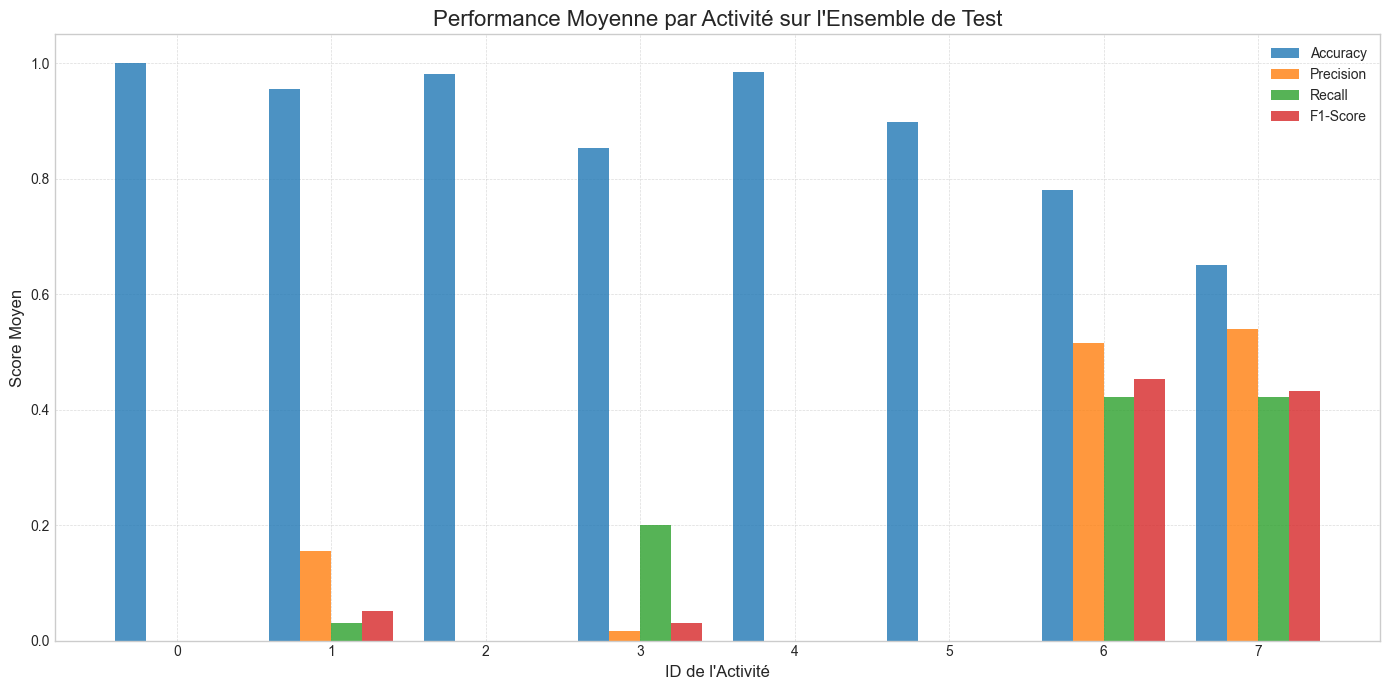

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if 'detailed_metrics_df' in globals():
    
    # 1. Agréger les métriques par activité en calculant la moyenne
    activity_mean_metrics = detailed_metrics_df.groupby('activityID').agg({
        'f1': 'mean',
        'precision': 'mean',
        'recall': 'mean',
        'accuracy': 'mean',
        'n_samples': 'sum',
        'n_fog_true': 'sum'
    }).reset_index()

    print("--- Métriques Moyennes par Activité (sur tous les sujets de test) ---")
    display(activity_mean_metrics.round(3))

    # 2. Créer le graphique
    activities = activity_mean_metrics['activityID'].astype(str)
    x = np.arange(len(activities))
    width = 0.2  # Largeur des barres

    fig, ax = plt.subplots(figsize=(14, 7))

    # Barres pour chaque métrique
    ax.bar(x - 1.5*width, activity_mean_metrics['accuracy'], width, label='Accuracy', alpha=0.8)
    ax.bar(x - 0.5*width, activity_mean_metrics['precision'], width, label='Precision', alpha=0.8)
    ax.bar(x + 0.5*width, activity_mean_metrics['recall'], width, label='Recall', alpha=0.8)
    ax.bar(x + 1.5*width, activity_mean_metrics['f1'], width, label='F1-Score', alpha=0.8)

    # Mise en forme du graphique
    ax.set_title('Performance Moyenne par Activité sur l\'Ensemble de Test', fontsize=16)
    ax.set_ylabel('Score Moyen', fontsize=12)
    ax.set_xlabel('ID de l\'Activité', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(activities)
    ax.set_ylim(0, 1.05)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

else:
    print("Le DataFrame 'detailed_metrics_df' n'a pas été trouvé.")
    print("Veuillez d'abord exécuter la cellule qui calcule les métriques détaillées par sujet et activité.")


In [416]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def per_subject_activity_metrics(metrics_run, df_quat_in, subjects_list_in, threshold=0.4):
    """
    Calculate performance metrics for each activity within each subject in the test set.
    """
    if not metrics_run or 'best_eval' not in metrics_run:
        print("Error: Metrics not found or incomplete. Please run the 'fog_hard' experiment first.")
        return pd.DataFrame()

    # 1. Get true labels, predicted probabilities, subject IDs, and activity IDs for the test set
    y_true_full = np.array(metrics_run['best_eval']['test_true'])
    y_prob_full = np.array(metrics_run['best_eval']['test_prob'])
    
    # We use the error analysis segmentation function which provides all necessary IDs
    _, _, subject_ids_full, activity_ids_full = segment_data_for_error_analysis(df_quat_in, subjects_list_in)

    if subject_ids_full is None:
        print("Error during data segmentation for analysis.")
        return pd.DataFrame()
        
    # --- Validation Check ---
    if not (len(y_true_full) == len(subject_ids_full) == len(activity_ids_full)):
        print("Error: Length mismatch between predictions and segmented IDs. Please re-run experiments.")
        return pd.DataFrame()

    # 2. Create a detailed DataFrame for analysis
    y_pred_full = (y_prob_full > threshold).astype(int)
    
    analysis_df = pd.DataFrame({
        'SubjectID': subject_ids_full,
        'ActivityID': activity_ids_full,
        'y_true': y_true_full,
        'y_pred': y_pred_full
    })

    # 3. Group by both Subject and Activity and calculate metrics
    
    # Use .apply() with a custom function to calculate metrics for each group
    def calculate_metrics(group):
        f1 = f1_score(group['y_true'], group['y_pred'], zero_division=0)
        precision = precision_score(group['y_true'], group['y_pred'], zero_division=0)
        recall = recall_score(group['y_true'], group['y_pred'], zero_division=0)
        accuracy = accuracy_score(group['y_true'], group['y_pred'])
        
        return pd.Series({
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Accuracy': accuracy,
            'Num_Samples': len(group),
            'FoG_Samples': group['y_true'].sum()
        })

    # Group by Subject and Activity and apply the function
    detailed_metrics_df = analysis_df.groupby(['SubjectID', 'ActivityID']).apply(calculate_metrics).reset_index()

    return detailed_metrics_df

# --- Run the detailed analysis ---
if 'metrics_fog' in globals():
    print("Performance par Sujet et par Activité (Modèle: fog_hard, Seuil=0.4)")
    
    # Calculate the detailed metrics
    subject_activity_df = per_subject_activity_metrics(metrics_fog, df_quat, test_subjects, threshold=0.4)
    
    # Display the results, sorted for readability
    with pd.option_context('display.max_rows', None): # Temporarily display all rows
        display(subject_activity_df.sort_values(by=['SubjectID', 'ActivityID']).round(3))
else:
    print("Veuillez exécuter l'entraînement 'fog_hard' (cellule 20) pour générer les métriques avant de lancer cette analyse.")


Performance par Sujet et par Activité (Modèle: fog_hard, Seuil=0.4)


,SubjectID,ActivityID,F1-Score,Precision,Recall,Accuracy,Num_Samples,FoG_Samples
0,4,1,0.000,0.000,0.000,0.975,198.0,0.0
1,4,2,0.000,0.000,0.000,1.000,36.0,0.0
2,4,3,0.000,0.000,0.000,0.886,88.0,0.0
3,4,4,0.000,0.000,0.000,0.976,42.0,0.0
4,4,5,0.000,0.000,0.000,0.931,29.0,0.0
5,4,6,0.000,0.000,0.000,0.651,63.0,0.0
6,4,7,0.278,0.185,0.556,0.675,80.0,9.0
7,8,1,0.000,0.000,0.000,1.000,77.0,0.0
8,8,2,0.000,0.000,0.000,0.944,36.0,0.0
9,8,3,0.000,0.000,0.000,0.722,18.0,0.0


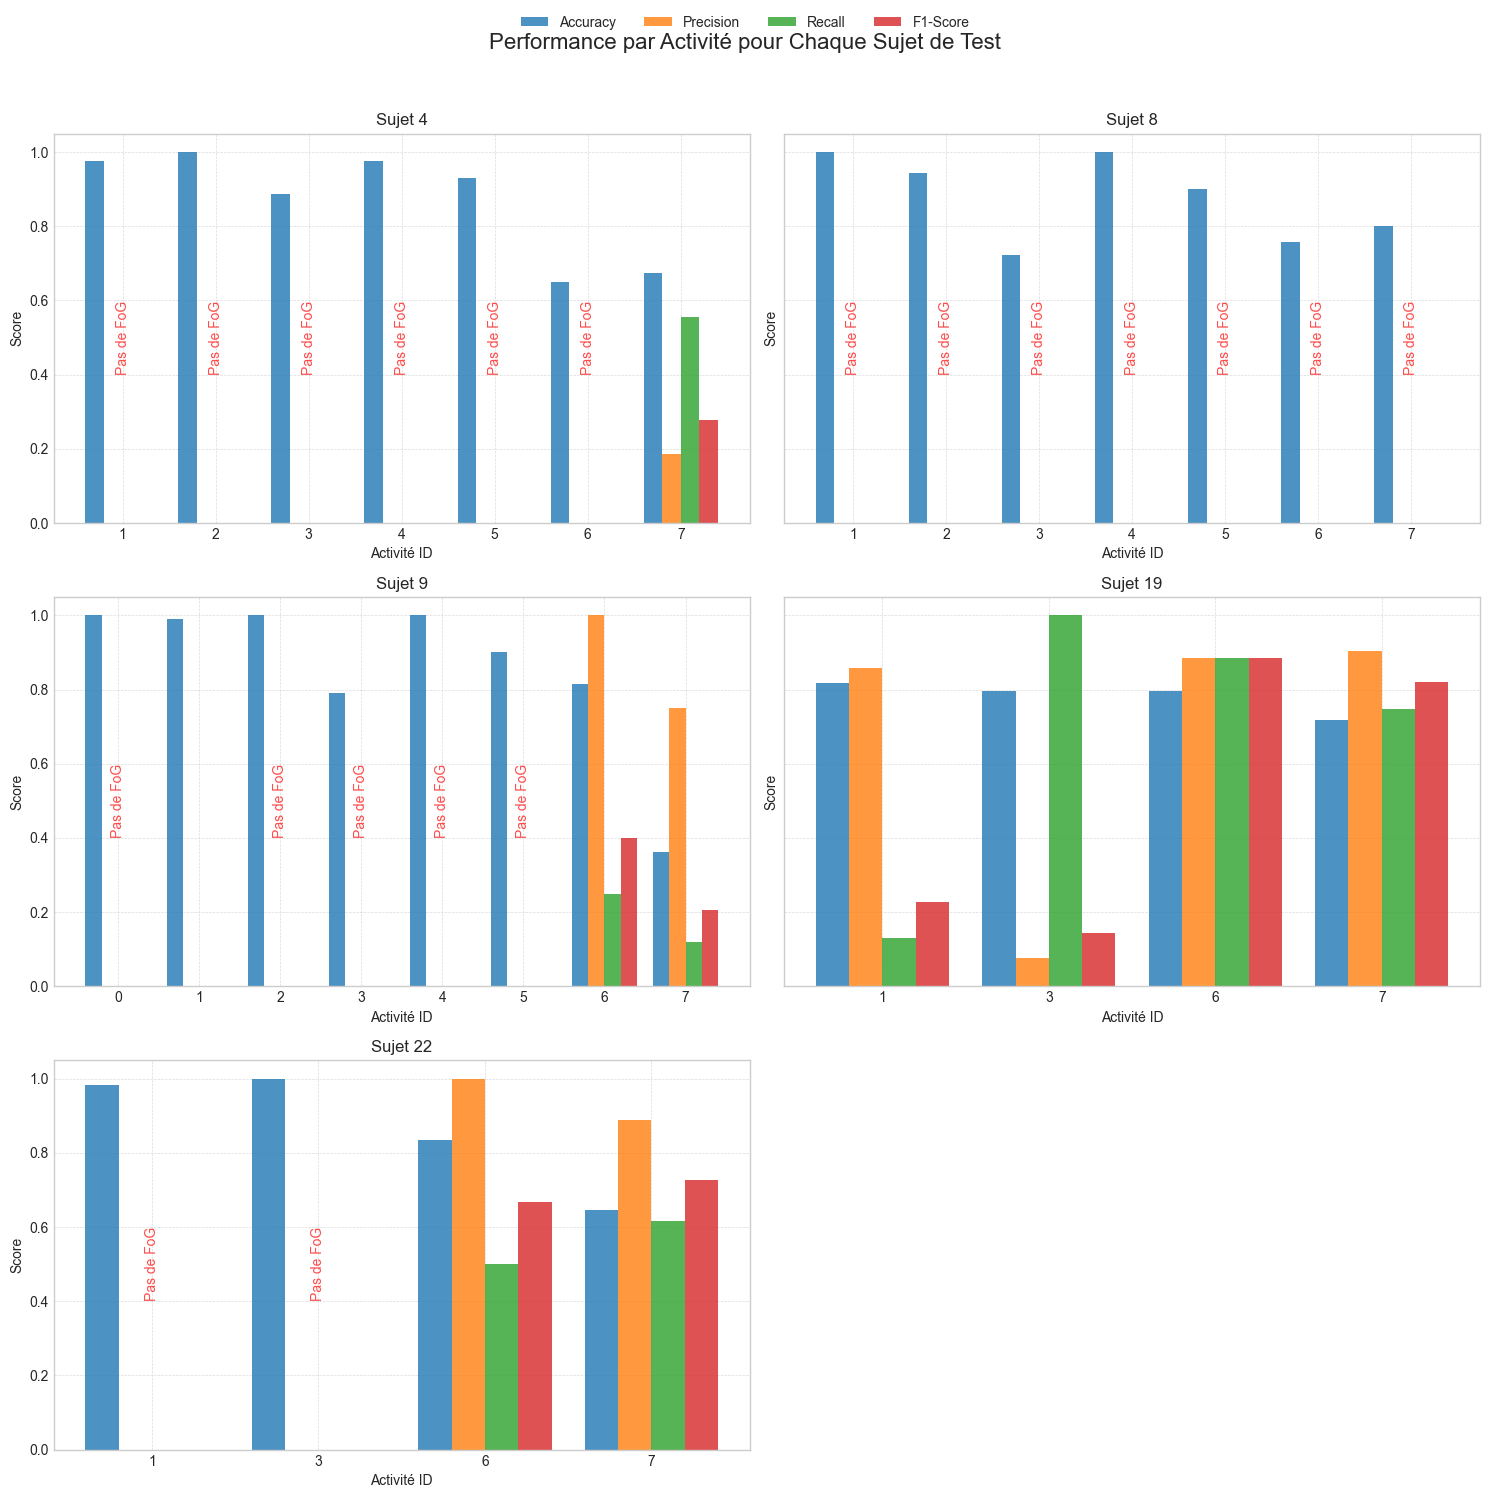

In [417]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Assurez-vous que le DataFrame 'subject_activity_df' existe
if 'subject_activity_df' in globals():
    
    subjects = sorted(subject_activity_df['SubjectID'].unique())
    n_subjects = len(subjects)
    
    # Déterminer la disposition de la grille de subplots
    n_cols = 2
    n_rows = math.ceil(n_subjects / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5), sharey=True)
    axes = axes.flatten() # Aplatir la grille pour une itération facile

    for i, subject_id in enumerate(subjects):
        ax = axes[i]
        sub_df = subject_activity_df[subject_activity_df['SubjectID'] == subject_id]
        
        activities = sub_df['ActivityID'].astype(str)
        x = np.arange(len(activities))
        width = 0.2

        # Barres pour chaque métrique
        ax.bar(x - 1.5*width, sub_df['Accuracy'], width, label='Accuracy', alpha=0.8)
        ax.bar(x - 0.5*width, sub_df['Precision'], width, label='Precision', alpha=0.8)
        ax.bar(x + 0.5*width, sub_df['Recall'], width, label='Recall', alpha=0.8)
        ax.bar(x + 1.5*width, sub_df['F1-Score'], width, label='F1-Score', alpha=0.8)

        # Mise en forme de l'axe
        ax.set_title(f'Sujet {subject_id}')
        ax.set_ylabel('Score')
        ax.set_xlabel('Activité ID')
        ax.set_xticks(x)
        ax.set_xticklabels(activities)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.set_ylim(0, 1.05)
        
        # Mettre en évidence les activités sans FoG
        for local_index, row in enumerate(sub_df.itertuples()):
            if row.FoG_Samples == 0:
                ax.text(x[local_index], 0.5, 'Pas de FoG', ha='center', va='center', rotation=90, color='red', alpha=0.7)

    # Ajouter une seule légende pour toute la figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0))

    # Cacher les axes inutilisés s'il y a un nombre impair de sujets
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Performance par Activité pour Chaque Sujet de Test', fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuster pour le titre principal
    plt.show()

else:
    print("Le DataFrame 'subject_activity_df' n'a pas été trouvé.")
    print("Veuillez d'abord exécuter la cellule précédente pour calculer les métriques détaillées.")


## Per-activity analysis

--- Error analysis for subject 19, activity 1 ---


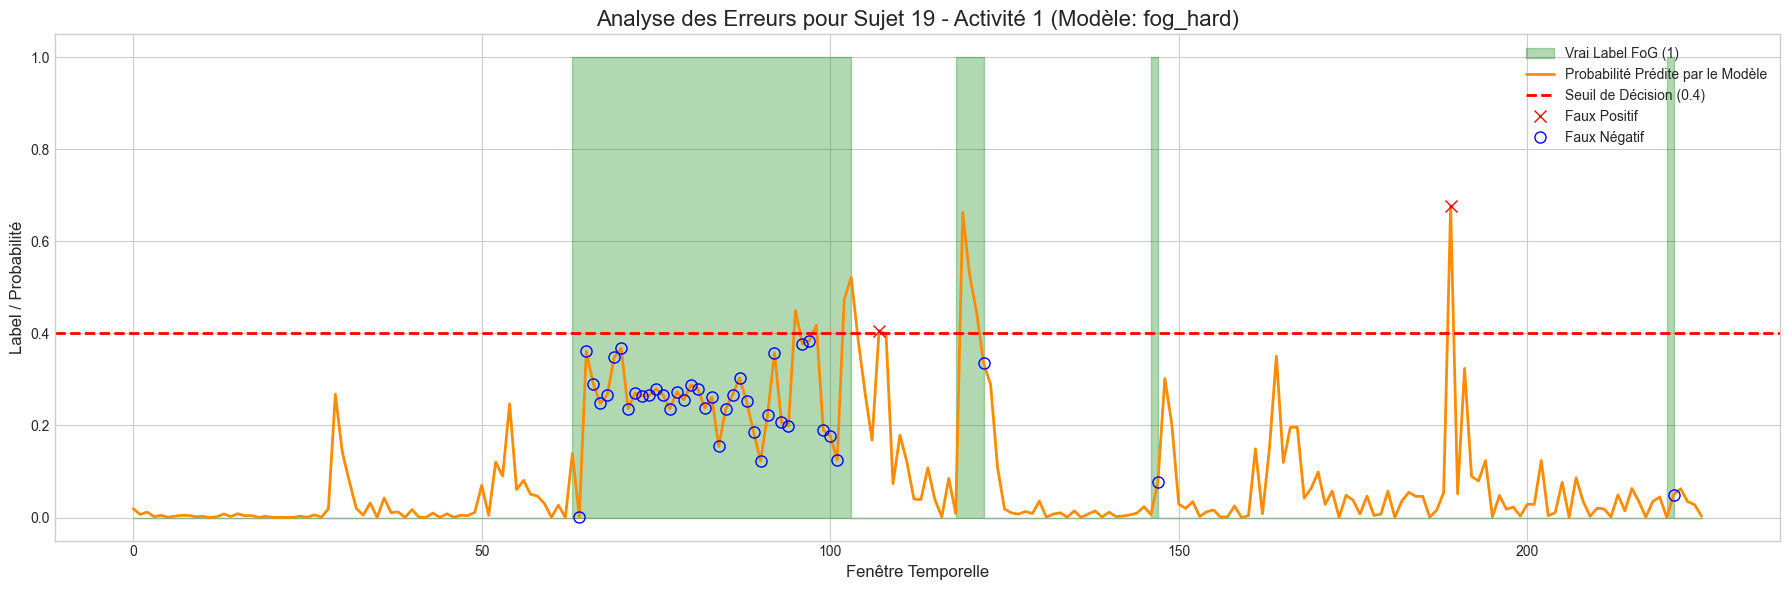


--- Error analysis for subject 19, activity 3 ---


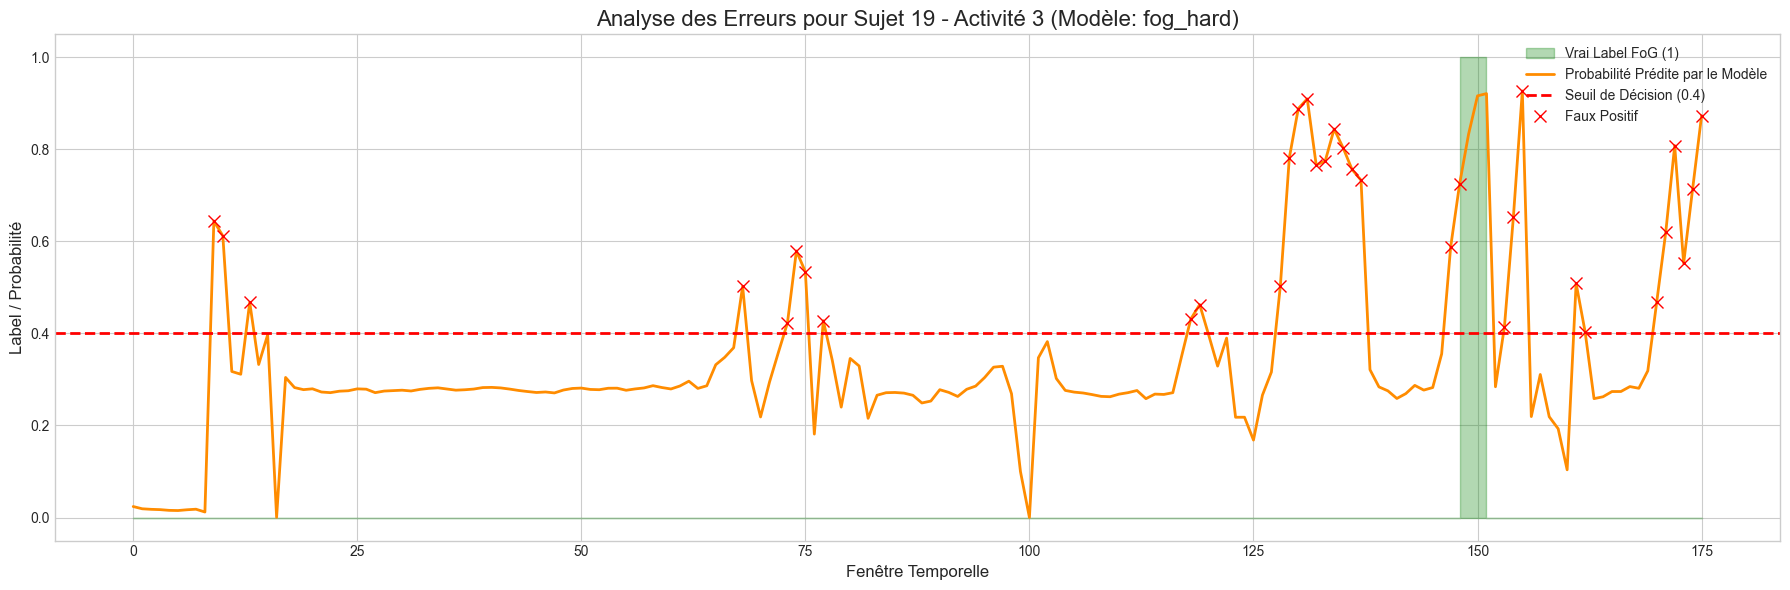

In [ ]:
# --- Investigation Ciblée : Sujet 19, Activités 1 et 3 ---

if 'metrics_fog' in globals() and 'plot_subject_activity_predictions' in globals():
    
    SUBJECT_ID = 19
    THRESHOLD = 0.4 # Le seuil que nous utilisons pour l'évaluation

    # --- Graphique pour l'Activité 1 ---
    print(f"--- Error analysis for subject {SUBJECT_ID}, activity 1 ---")
    plot_subject_activity_predictions(
        metrics_run=metrics_fog_hard, 
        df_quat_in=df_quat, 
        subjects_list_in=test_subjects, 
        subject_to_plot=SUBJECT_ID, 
        activity_to_plot=1, 
        threshold=THRESHOLD
    )
    
    # --- Graphique pour l'Activité 3 ---
    print(f"\n--- Error analysis for subject {SUBJECT_ID}, activity 3 ---")
    plot_subject_activity_predictions(
        metrics_run=metrics_fog_hard, 
        df_quat_in=df_quat, 
        subjects_list_in=test_subjects, 
        subject_to_plot=SUBJECT_ID, 
        activity_to_plot=3, 
        threshold=THRESHOLD
    )

else:
    print("Veuillez vous assurer que les cellules 20 (entraînement 'fog_hard') et 24 (définition de la fonction de plot) ont été exécutées.")


In [334]:
results_df.head()

,Subject,F1-Score,Precision,Recall,Num Samples,Accuracy,FoG Samples,Has FoG
0,4,0.170732,0.095890,0.777778,536,0.873134,9,True
1,8,0.000000,0.000000,0.000000,203,0.871921,0,False
2,9,0.441176,0.625000,0.340909,493,0.922921,44,True
3,19,0.752026,0.808362,0.703030,727,0.789546,330,True
4,22,0.827586,0.857143,0.800000,90,0.944444,15,True


In [426]:
from sklearn.metrics import classification_report

def segment_data_for_eval(df, subjects, w=2, o=0.75, fs=60):
    """Segments data and returns activity and subject labels for each window."""
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    activities, subject_ids = [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        if sub_df.empty or 'activity' not in sub_df.columns:
            continue
            
        data = sub_df[cols].values
        acts = sub_df['activity'].values
        
        for i in range(0, len(data) - win_size, step):
            activities.append(pd.Series(acts[i:i + win_size]).mode()[0])
            subject_ids.append(sub)
            
    return np.array(activities, dtype=int), np.array(subject_ids, dtype=int)


def evaluate_with_activity_thresholds(metrics_run, df_quat_in, subjects_list_in, activity_thresholds, default_threshold=0.4):
    """
    Evaluates model performance using specific thresholds for different activities.
    """
    if 'best_eval' not in metrics_run:
        print("Erreur: L'objet 'metrics_run' ne contient pas les résultats détaillés ('best_eval').")
        print("Veuillez ré-exécuter l'entraînement (cellule 18) pour générer ces résultats.")
        return

    # 1. Récupérer les prédictions et les vraies étiquettes
    y_true = np.array(metrics_run['best_eval']['test_true'])
    y_prob = np.array(metrics_run['best_eval']['test_prob'])
    
    # 2. Récupérer les étiquettes d'activité pour chaque fenêtre de prédiction
    activities_per_window, _ = segment_data_for_eval(df_quat_in, subjects_list_in)
    
    if len(y_true) != len(activities_per_window):
        print(f"Erreur de correspondance de longueur: {len(y_true)} prédictions vs {len(activities_per_window)} étiquettes d'activité.")
        return

    # 3. Appliquer les seuils personnalisés
    y_pred = np.zeros_like(y_true)
    for i in range(len(y_prob)):
        activity = activities_per_window[i]
        threshold = activity_thresholds.get(activity, default_threshold)
        if y_prob[i] > threshold:
            y_pred[i] = 1
            
    # 4. Afficher les résultats
    print(f"--- Results with personnalized threshold: {activity_thresholds} ---")
    print("\n--- Global metrics ---")
    
    # Calcul des métriques globales
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"F1-Score glonal: {f1:.4f}")
    print(f"Precision global: {precision:.4f}")
    print(f"Recall globall: {recall:.4f}")
    print(f"Accuracy global: {accuracy:.4f}")
    
    print("\n--- Detailed metrics per activity ---")
    report = classification_report(y_true, y_pred, target_names=['No FoG', 'FoG'], output_dict=True, zero_division=0)
    
    activity_results = []
    unique_activities = sorted(np.unique(activities_per_window))
    
    for act_id in unique_activities:
        idx = (activities_per_window == act_id)
        act_y_true = y_true[idx]
        act_y_pred = y_pred[idx]
        
        if len(act_y_true) > 0:
            activity_results.append({
                'ActivityID': act_id,
                'F1 Score': f1_score(act_y_true, act_y_pred, zero_division=0),
                'Precision': precision_score(act_y_true, act_y_pred, zero_division=0),
                'Recall': recall_score(act_y_true, act_y_pred, zero_division=0),
                'Accuracy': accuracy_score(act_y_true, act_y_pred),
                'Samples': len(act_y_true),
                'FoG True': act_y_true.sum(),
                'FoG Pred': act_y_pred.sum()
            })
            
    display(pd.DataFrame(activity_results).round(3))

In [427]:
# Définissez ici vos seuils personnalisés par activité
custom_thresholds = {
    1: 0.2,  # Seuil plus bas pour l'activité 1
    3: 0.85   # Seuil plus élevé pour l'activité 3
}

# Assurez-vous que l'expérience 'fog_hard' a été exécutée
if 'metrics_fog' in globals():
    evaluate_with_activity_thresholds(
        metrics_fog, 
        df_quat, 
        test_subjects, 
        activity_thresholds=custom_thresholds,
        default_threshold=0.325 # Seuil pour toutes les autres activités
    )
else:
    print("Veuillez exécuter l'expérience 'fog_hard' (cellule 18) avant d'évaluer avec des seuils personnalisés.")

--- Results with personnalized threshold: {1: 0.2, 3: 0.85} ---

--- Global metrics ---
F1-Score glonal: 0.7423
Precision global: 0.7009
Recall globall: 0.7889
Accuracy global: 0.8936

--- Detailed metrics per activity ---


,ActivityID,F1 Score,Precision,Recall,Accuracy,Samples,FoG True,FoG Pred
0,0,0.000,0.000,0.000,1.000,41,0,0
1,1,0.685,0.613,0.776,0.960,865,49,62
2,2,0.000,0.000,0.000,0.949,79,0,4
3,3,0.444,0.333,0.667,0.984,315,3,6
4,4,0.000,0.000,0.000,0.960,50,0,2
5,5,0.000,0.000,0.000,0.898,49,0,5
6,6,0.718,0.637,0.823,0.757,255,96,124
7,7,0.788,0.796,0.780,0.734,395,250,245


In [420]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from sklearn.metrics import f1_score, precision_score, recall_score

# --- Analyse de l'Impact du Filtre Médian ---

# Assurez-vous que l'expérience 'fog_hard' a été exécutée
if 'metrics_fog' in globals():
    
    print("--- Analyse de l'impact du post-traitement par Filtre Médian ---")
    
    # 1. Récupérer les résultats du meilleur modèle de l'expérience 'fog_hard'
    eval_results = metrics_fog.get('best_eval')
    
    if eval_results:
        y_true = np.array(eval_results['test_true'])
        y_prob = np.array(eval_results['test_prob'])
        
        # Utiliser le meilleur seuil trouvé lors de l'évaluation
        threshold = eval_results.get('best_threshold_from_val_f1', 0.4)
        
        # Prédictions brutes avant filtrage
        y_pred_raw = (y_prob > threshold).astype(int)
        
        # Liste pour stocker les résultats
        comparison_results = []
        
        # Ajouter les métriques du modèle brut (sans filtre)
        comparison_results.append({
            'Filter Type': 'None (Raw Predictions)',
            'Kernel Size': 'N/A',
            'F1-Score': f1_score(y_true, y_pred_raw, zero_division=0),
            'Precision': precision_score(y_true, y_pred_raw, zero_division=0),
            'Recall': recall_score(y_true, y_pred_raw, zero_division=0)
        })
        
        # 2. Tester différentes tailles de noyau pour le filtre médian
        kernel_sizes_to_test = [3, 5, 7, 9, 11]
        
        for k_size in kernel_sizes_to_test:
            # Appliquer le filtre médian
            y_pred_filtered = medfilt(y_pred_raw, kernel_size=k_size)
            
            # Calculer les métriques pour les prédictions filtrées
            comparison_results.append({
                'Filter Type': 'Median Filter',
                'Kernel Size': k_size,
                'F1-Score': f1_score(y_true, y_pred_filtered, zero_division=0),
                'Precision': precision_score(y_true, y_pred_filtered, zero_division=0),
                'Recall': recall_score(y_true, y_pred_filtered, zero_division=0)
            })
            
        # 3. Afficher le tableau comparatif
        results_df = pd.DataFrame(comparison_results)
        print(f"\nComparaison des métriques avec un seuil de {threshold:.3f}")
        display(results_df.round(4))
        
    else:
        print("L'objet 'metrics_fog' ne contient pas les résultats détaillés ('best_eval').")
        print("Veuillez ré-exécuter l'entraînement pour générer ces résultats.")

else:
    print("Les résultats de l'expérience 'fog_hard' ('metrics_fog') n'ont pas été trouvés.")
    print("Veuillez d'abord exécuter la cellule de l'expérience 'fog_hard'.")


--- Analyse de l'impact du post-traitement par Filtre Médian ---

Comparaison des métriques avec un seuil de 0.325


,Filter Type,Kernel Size,F1-Score,Precision,Recall
0,None (Raw Predictions),N/A,0.6606,0.6059,0.7261
1,Median Filter,3,0.6728,0.6213,0.7337
2,Median Filter,5,0.6868,0.6399,0.7412
3,Median Filter,7,0.6856,0.6494,0.7261
4,Median Filter,9,0.6988,0.6713,0.7286
5,Median Filter,11,0.7063,0.6831,0.7312


## Graph performance with personalized thresholds

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/var/folders/5w/6s16lbnx19g0d7hy__grtsb40000gn/T/ipykernel_18210/1160352631.py:19: SyntaxWarning: invalid escape sequence '\s'
  plot_df = pd.read_csv(io.StringIO(data_string), sep='\s+')


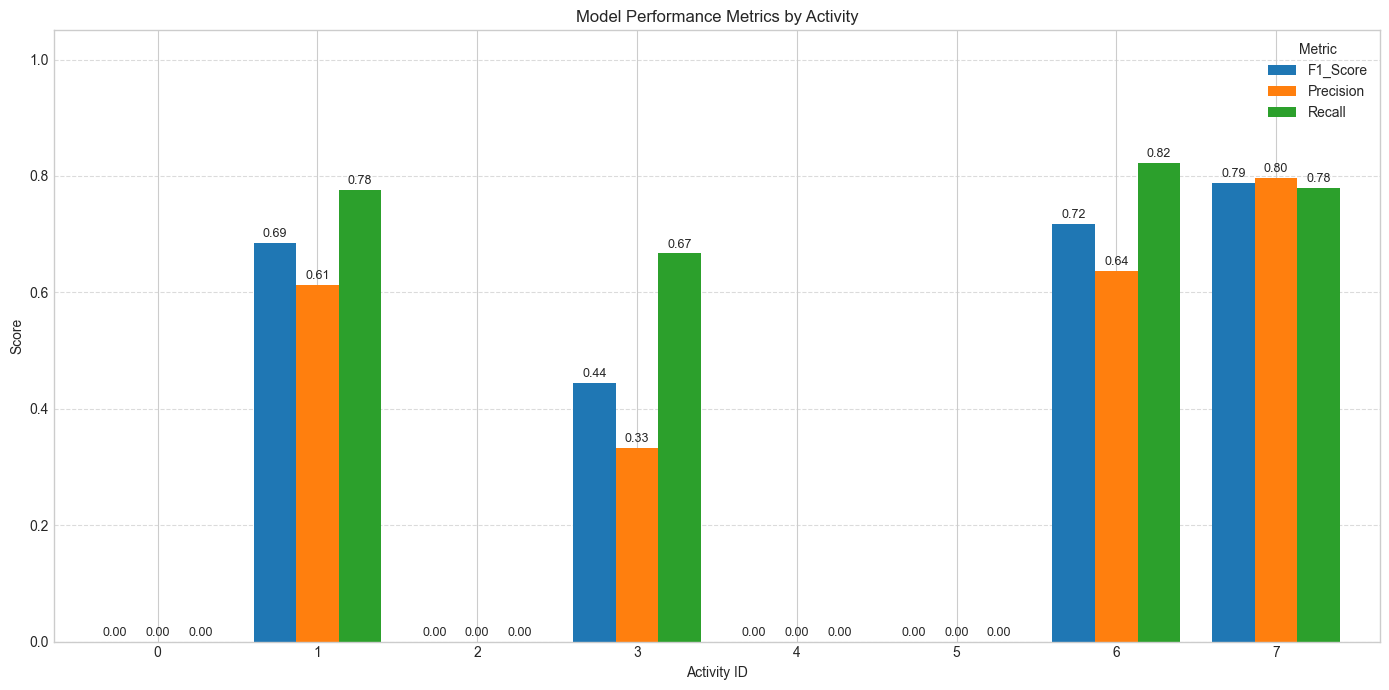

In [424]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# Data provided by the user in string format
data_string = """ActivityID	F1_Score	Precision	Recall	Samples	FoG_True	FoG_Pred
0	0.000	0.000	0.000	41	0	0
1	0.685	0.613	0.776	865	49	62
2	0.000	0.000	0.000	79	0	4
3	0.444	0.333	0.667	315	3	6
4	0.000	0.000	0.000	50	0	2
5	0.000	0.000	0.000	49	0	5
6	0.718	0.637	0.823	255	96	124
7	0.788	0.796	0.780	395	250	245
"""

# Read the string data into a pandas DataFrame
# The separator is a tab, so we use sep='\s+' which handles one or more whitespace characters
plot_df = pd.read_csv(io.StringIO(data_string), sep='\s+')

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 7))

# Set the ActivityID as the index for plotting
plot_df_indexed = plot_df.set_index('ActivityID')

# Select only the metric columns to plot
metrics_to_plot = ['F1_Score', 'Precision', 'Recall']
plot_df_indexed[metrics_to_plot].plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Model Performance Metrics by Activity')
ax.set_xlabel('Activity ID')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Metric')
ax.set_ylim(0, 1.05) # Set y-axis limit to be from 0 to 1.05 for better visualization

# Annotate bars with their values
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=2)

plt.tight_layout()
plt.show()
